## Stock Market Risk Analysis using PCA, Factor Analysis and Clustering

This project analyses monthly NYSE stock returns using Python. The main goal is to identify common market risk patterns, industry-level systematic risk, and stocks that move closely with the S&P500 market return.

The analysis applies high-dimensional data analysis techniques such as Principal Component Analysis, Factor Analysis, clustering, Multidimensional Scaling, and correlation analysis.

## Project Objective

The objective of this project is to examine whether a large set of stock returns can be explained by a smaller number of common risk factors.

Specifically, this project aims to:

1. Identify the main common movement across stocks using PCA.
2. Check whether the first principal component behaves like the overall market.
3. Analyse industry-level exposure to common factors.
4. Measure systematic risk using Factor Analysis through communality.
5. Recommend five stocks that move closely with the market.
6. Use clustering and visualisation methods to validate stock behaviour patterns.

## Dataset Description

Two datasets are used in this project:

- `Market.csv`: contains the S&P500 monthly market return.
- `SampleI.csv`: contains monthly returns of 92 NYSE stocks.

The data covers 180 monthly observations from January 2005 to December 2019.

Each stock identifier begins with an industry code. The first letter indicates the industry group, while the remaining digits represent the stock identifier.

Industry code mapping:

- B = Mining
- C = Construction
- D = Manufacturing
- E = Transportation and Public Utilities
- F = Wholesale Trade
- G = Retail Trade
- H = Finance, Insurance and Real Estate
- I = Services

## Methodology Overview

The analysis is structured in the following stages:

1. **Data loading and inspection**  
   Load the market and stock return datasets and check their structure.

2. **Data quality check**  
   Check missing values, date range, number of stocks, and industry representation.

3. **Exploratory Data Analysis**  
   Summarise stock returns, industry-level volatility, market movements, and outliers.

4. **Principal Component Analysis**  
   Reduce 92 stock-return variables into a smaller number of principal components and test whether PC1 behaves like the market.

5. **Factor Analysis**  
   Estimate hidden common factors and calculate uniqueness and communality to measure systematic risk.

6. **Stock recommendation**  
   Rank stocks using market correlation, PC1 loading, Factor 1 loading, and communality.

7. **Clustering and visual validation**  
   Use K-means, hierarchical clustering, Gaussian Mixture Model, and MDS to examine stock similarity patterns.

8. **Correlation analysis**  
   Examine stock-market and stock-to-stock co-movement.

## 1. Import Required Libraries

The required Python libraries are imported in this section.

- `pandas` is used for data loading, cleaning, and tabular analysis.
- `numpy` is used for numerical calculations.
- `matplotlib` and `seaborn` are used for data visualisation.
- `scikit-learn` is used for PCA, scaling, and clustering.
- `factor_analyzer` is used for Factor Analysis.
- `scipy` is used for hierarchical clustering.
- `warnings` is used to hide unnecessary warning messages.

These libraries provide the tools needed to perform exploratory analysis, dimensionality reduction, factor modelling, clustering, and visualisation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries are imported successfully")

Libraries are imported successfully


## 2. Load the Data

The market return dataset and the stock return dataset are loaded from the `data` folder.

The market dataset contains the S&P500 monthly return, while the stock dataset contains the monthly returns of 92 NYSE stocks.

Both datasets contain a common `Date` column, which will later be used to combine the market and stock return data.

In [2]:
market_data = pd.read_csv("../data/Market.csv")
stock_data = pd.read_csv("../data/SampleI.csv")
print("Data loaded successfully")

Data loaded successfully


In [3]:
print("Market Data size-", market_data.shape )
print("Stock Data size-", stock_data.shape)

Market Data size- (180, 2)
Stock Data size- (180, 93)


The market dataset contains 180 monthly observations and 2 columns: `Date` and `MarketReturn`.

The stock dataset contains 180 monthly observations and 93 columns. One column is `Date`, and the remaining 92 columns represent individual stock returns.

This confirms that the dataset covers 180 months of observations and 92 stock-return variables.

## 3. Preview the Datasets

After checking the dataset size, we preview the first few rows to understand the column structure and the format of the values.

In [4]:
market_data.head(5)


,Date,MarketReturn
0,Y2005M1,-2.76
1,Y2005M2,1.89
2,Y2005M3,-1.97
3,Y2005M4,-2.61
4,Y2005M5,3.65


In [5]:
stock_data.head(5)

,Date,E40440,H76123,H79048,F54199,H86871,D82932,D18729,G81540,B89509,...,G66376,H12166,G11618,E43481,I87361,I88203,B79444,H85763,G66181,E88439
0,Y2005M1,-0.033914,0.071651,-0.031796,-0.066758,0.019453,-0.030347,0.031665,-0.006817,-0.043536,...,-0.013345,0.078431,-0.023229,0.011583,-0.029004,0.176737,-0.050787,-0.081342,-0.034628,-0.106533
1,Y2005M2,-0.004922,0.055959,0.049496,0.048499,-0.004914,0.043219,0.007233,0.028226,0.121931,...,0.102571,0.116796,-0.022618,0.010409,-0.019480,-0.127086,0.173598,0.047059,-0.030053,0.086614
2,Y2005M3,0.027731,-0.071714,-0.081193,-0.006223,-0.038277,0.017000,-0.014172,-0.043573,-0.041062,...,0.103249,-0.017760,-0.054054,-0.055690,-0.025166,-0.076471,-0.033048,-0.088882,-0.041979,0.023810
3,Y2005M4,-0.118140,0.034027,-0.006394,0.088813,0.059109,0.019144,-0.040061,0.069646,-0.089744,...,0.033967,-0.020167,-0.032188,-0.040293,-0.016304,0.146497,-0.074738,-0.022061,-0.075052,-0.129424
4,Y2005M5,0.039177,0.133353,0.056867,0.110261,0.017959,0.067680,0.003615,0.054096,0.060000,...,0.018437,0.061973,0.085949,0.029389,0.009669,0.383333,-0.042501,-0.025253,0.112525,0.126597


## 4. Check Column Names

Column names are checked to confirm that the expected variables are present in both datasets. This is important because Python is case-sensitive, and later analysis depends on exact column names such as `Date` and `MarketReturn`.

In [6]:
print("Market data columns:")
print(market_data.columns.tolist())

print("\nFirst 10 stock data columns:")
print(stock_data.columns[:10]. tolist())

Market data columns:
['Date', 'MarketReturn']

First 10 stock data columns:
['Date', 'E40440', 'H76123', 'H79048', 'F54199', 'H86871', 'D82932', 'D18729', 'G81540', 'B89509']


In [7]:
print("Market data shape:", market_data.shape)
print("Stock data shape:", stock_data.shape)

Market data shape: (180, 2)
Stock data shape: (180, 93)


The column name check confirms that both datasets contain the expected variables.

The market dataset contains two columns: `Date` and `MarketReturn`.

The stock dataset contains a `Date` column followed by stock identifiers such as `E40440`, `H76123`, and `H79048`. The first letter of each stock identifier represents the industry code, which will be used later for industry-level analysis.

This check is important because later steps depend on exact column names such as `Date` and `MarketReturn`.

## 5. Missing Value Check

Before applying PCA, Factor Analysis, and clustering, missing values must be checked carefully. These methods require numerical data, and missing values can cause errors or produce unreliable results.

In this step, we check missing values in both the market dataset and the stock return dataset.

In [8]:
print("Missing values in market data:")
print(market_data.isna().sum())

print("\nTotal missing values in stock data:")
print(stock_data.isna().sum().sum())

print("\nNumber of columns with missing values in stock data:")
print((stock_data.isna().sum() > 0).sum())

Missing values in market data:
Date            0
MarketReturn    0
dtype: int64

Total missing values in stock data:
0

Number of columns with missing values in stock data:
0


The missing value check shows that there are no missing values in either the market dataset or the stock return dataset.

Therefore, no imputation or row deletion is required before the modelling stage.

## 6. Create Working DataFrames

After loading and checking the datasets, we create three working dataframes:

- `stock_df`: contains only stock-return columns and is used for PCA, Factor Analysis, and clustering.
- `join_data`: combines the market return and stock returns using the `Date` column.
- `stock_long`: reshapes the stock data from wide format to long format for exploratory analysis and industry-level summaries.

In [9]:
stock_df = stock_data.drop(columns=["Date"])

print("Stock-only dataframe shape:", stock_df.shape)

Stock-only dataframe shape: (180, 92)


The `stock_df` dataframe contains 180 monthly observations and 92 stock-return columns.

The `Date` column has been removed because PCA, Factor Analysis, clustering, and correlation analysis require numerical stock-return variables only.

In [10]:
join_data = pd.merge(market_data, stock_data, on="Date", how="inner")

print("Joined dataset shape:", join_data.shape)
join_data.head()

Joined dataset shape: (180, 94)


,Date,MarketReturn,E40440,H76123,H79048,F54199,H86871,D82932,D18729,G81540,...,G66376,H12166,G11618,E43481,I87361,I88203,B79444,H85763,G66181,E88439
0,Y2005M1,-2.76,-0.033914,0.071651,-0.031796,-0.066758,0.019453,-0.030347,0.031665,-0.006817,...,-0.013345,0.078431,-0.023229,0.011583,-0.029004,0.176737,-0.050787,-0.081342,-0.034628,-0.106533
1,Y2005M2,1.89,-0.004922,0.055959,0.049496,0.048499,-0.004914,0.043219,0.007233,0.028226,...,0.102571,0.116796,-0.022618,0.010409,-0.019480,-0.127086,0.173598,0.047059,-0.030053,0.086614
2,Y2005M3,-1.97,0.027731,-0.071714,-0.081193,-0.006223,-0.038277,0.017000,-0.014172,-0.043573,...,0.103249,-0.017760,-0.054054,-0.055690,-0.025166,-0.076471,-0.033048,-0.088882,-0.041979,0.023810
3,Y2005M4,-2.61,-0.118140,0.034027,-0.006394,0.088813,0.059109,0.019144,-0.040061,0.069646,...,0.033967,-0.020167,-0.032188,-0.040293,-0.016304,0.146497,-0.074738,-0.022061,-0.075052,-0.129424
4,Y2005M5,3.65,0.039177,0.133353,0.056867,0.110261,0.017959,0.067680,0.003615,0.054096,...,0.018437,0.061973,0.085949,0.029389,0.009669,0.383333,-0.042501,-0.025253,0.112525,0.126597


The joined dataset contains 180 monthly observations and 94 columns.

It includes the `Date` column, the S&P500 `MarketReturn`, and 92 stock-return columns. This dataset will be used later to compare PC1 with the market return and to calculate stock-market correlations.

## 7. Industry Classification

Each stock identifier begins with a letter that represents the industry group. This industry code will be extracted from each stock identifier and mapped to the full industry name.

In [11]:
industry_map = {
    "B": "Mining",
    "C": "Construction",
    "D": "Manufacturing",
    "E": "Transportation and Public Utilities",
    "F": "Wholesale Trade",
    "G": "Retail Trade",
    "H": "Finance, Insurance and Real Estate",
    "I": "Services"
}

industry_map

{'B': 'Mining',
 'C': 'Construction',
 'D': 'Manufacturing',
 'E': 'Transportation and Public Utilities',
 'F': 'Wholesale Trade',
 'G': 'Retail Trade',
 'H': 'Finance, Insurance and Real Estate',
 'I': 'Services'}

The industry mapping dictionary links each industry code to its full industry name.

This mapping will be used later to convert stock identifiers such as `H76123` into an industry group such as Finance, Insurance and Real Estate.

## Count stocks by industry

In [12]:
stock_columns = stock_df.columns

industry_counts = pd.Series([col[0] for col in stock_columns]).value_counts().sort_index()

industry_counts_df = industry_counts.reset_index()
industry_counts_df.columns = ["Industry_Code", "Number_of_Stocks"]
industry_counts_df["Industry_Name"] = industry_counts_df["Industry_Code"].map(industry_map)

industry_counts_df

,Industry_Code,Number_of_Stocks,Industry_Name
0,B,4,Mining
1,D,7,Manufacturing
2,E,18,Transportation and Public Utilities
3,F,10,Wholesale Trade
4,G,8,Retail Trade
5,H,37,"Finance, Insurance and Real Estate"
6,I,8,Services


The number of stocks in each industry group is calculated using the first letter of each stock identifier.

This helps understand the industry composition of the dataset before applying PCA, Factor Analysis, and clustering.

## 8. Reshape Stock Data into Long Format

The stock return dataset is reshaped from wide format to long format.

In the original wide format, each stock has its own column. In the long format, each row represents one stock's return for one month.

This format is useful for industry-level summaries, return distribution plots, outlier analysis, and grouped calculations.

In [13]:
stock_long = stock_data.melt(
    id_vars="Date",
    var_name="Stock_ID",
    value_name="Return"
)

stock_long["Industry_Code"] = stock_long["Stock_ID"].str[0]
stock_long["Industry_Name"] = stock_long["Industry_Code"].map(industry_map)

stock_long.head()

,Date,Stock_ID,Return,Industry_Code,Industry_Name
0,Y2005M1,E40440,-0.033914,E,Transportation and Public Utilities
1,Y2005M2,E40440,-0.004922,E,Transportation and Public Utilities
2,Y2005M3,E40440,0.027731,E,Transportation and Public Utilities
3,Y2005M4,E40440,-0.118140,E,Transportation and Public Utilities
4,Y2005M5,E40440,0.039177,E,Transportation and Public Utilities


The stock return data has been successfully converted into long format.

Each row now contains the month, stock identifier, monthly return, industry code, and industry name. This structure is easier to use for exploratory analysis and industry-level comparisons.

## 9. Exploratory Data Analysis

### 9.1 Data Readiness Summary

This section summarises the dataset size, sample period, and missing values before deeper exploratory analysis.

In [14]:
num_months = stock_data.shape[0]
num_stocks = stock_df.shape[1]

market_missing_total = market_data.isna().sum().sum()
stock_missing_total = stock_data.isna().sum().sum()

start_date = stock_data["Date"].iloc[0]
end_date = stock_data["Date"].iloc[-1]

data_quality_summary = pd.DataFrame({
    "Metric": [
        "Number of months",
        "Number of stocks",
        "Start period",
        "End period",
        "Missing values in market data",
        "Missing values in stock data"
    ],
    "Value": [
        num_months,
        num_stocks,
        start_date,
        end_date,
        market_missing_total,
        stock_missing_total
    ]
})

data_quality_summary

,Metric,Value
0,Number of months,180
1,Number of stocks,92
2,Start period,Y2005M1
3,End period,Y2019M12
4,Missing values in market data,0
5,Missing values in stock data,0


The summary confirms that the dataset has 180 monthly observations, 92 stock-return variables, and no missing values. The data is ready for EDA, PCA, Factor Analysis, clustering, and correlation analysis.

### 9.2 Industry Return Summary

This section calculates each stock's average return and volatility, grouped by industry and stock identifier.

In [15]:
industry_summary = (
    stock_long
    .groupby(["Industry_Code", "Industry_Name", "Stock_ID"])
    .agg(
        mean_return=("Return", "mean"),
        volatility=("Return", "std")
    )
    .reset_index()
)

industry_summary.head()

,Industry_Code,Industry_Name,Stock_ID,mean_return,volatility
0,B,Mining,B78877,-0.002910,0.158354
1,B,Mining,B79444,0.000626,0.222312
2,B,Mining,B84083,0.010149,0.183900
3,B,Mining,B89509,0.008539,0.112955
4,D,Manufacturing,D10026,0.014002,0.060611


The output shows stock-level average return and volatility within each industry. This helps compare return behaviour across industries before applying PCA, Factor Analysis, and clustering.

### 9.3 Industry-Level Return Summary

This section aggregates the stock-level return summary to compare average return, average volatility, and number of stocks across industries.

In [16]:
industry_return_summary = (
    industry_summary
    .groupby(["Industry_Code", "Industry_Name"])
    .agg(
        average_return=("mean_return", "mean"),
        average_volatility=("volatility", "mean"),
        number_of_stocks=("Stock_ID", "nunique")
    )
    .reset_index()
    .sort_values("Industry_Code")
)

industry_return_summary

,Industry_Code,Industry_Name,average_return,average_volatility,number_of_stocks
0,B,Mining,0.004101,0.169380,4
1,D,Manufacturing,0.012281,0.082348,7
2,E,Transportation and Public Utilities,0.011002,0.119406,18
3,F,Wholesale Trade,0.008139,0.100398,10
4,G,Retail Trade,0.009950,0.112907,8
5,H,"Finance, Insurance and Real Estate",0.006675,0.072436,37
6,I,Services,0.010311,0.127877,8


The table shows industry-level average return and volatility. It helps identify which industries had higher average returns and which industries experienced greater return variability during the sample period.

### 9.4 Convert Date Format

The original date format is converted into a proper datetime format so that market returns can be plotted over time.

In [17]:
market_data_plot = market_data.copy()

market_data_plot["Year"] = market_data_plot["Date"].str.extract(r"Y(\d{4})").astype(int)
market_data_plot["Month"] = market_data_plot["Date"].str.extract(r"M(\d{1,2})").astype(int)

market_data_plot["Date_Formatted"] = pd.to_datetime(
    market_data_plot["Year"].astype(str) + "-" + market_data_plot["Month"].astype(str) + "-01"
)

market_data_plot.head()

,Date,MarketReturn,Year,Month,Date_Formatted
0,Y2005M1,-2.76,2005,1,2005-01-01
1,Y2005M2,1.89,2005,2,2005-02-01
2,Y2005M3,-1.97,2005,3,2005-03-01
3,Y2005M4,-2.61,2005,4,2005-04-01
4,Y2005M5,3.65,2005,5,2005-05-01


The date conversion creates separate year and month columns and a new `Date_Formatted` column. This makes the data suitable for time-series visualisation.

### 9.5 Plot Market Return

This section visualises the S&P500 monthly market return over time.

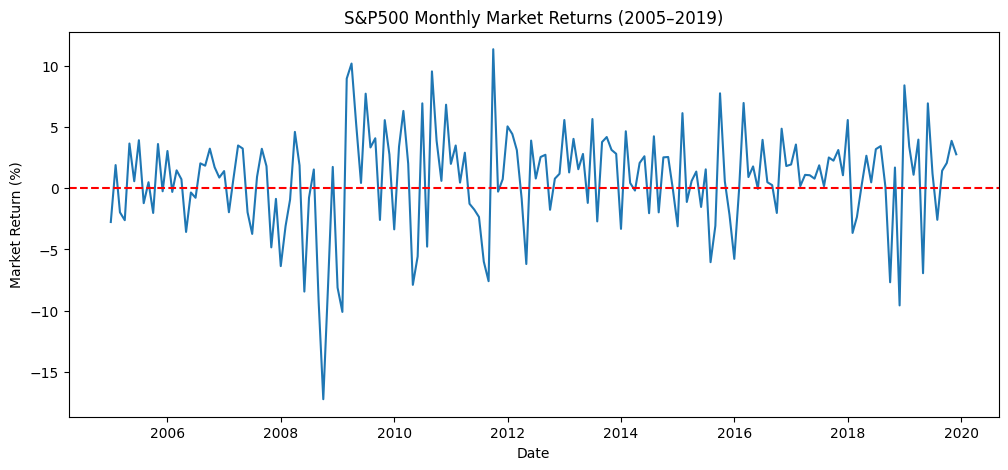

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    market_data_plot["Date_Formatted"],
    market_data_plot["MarketReturn"]
)

plt.axhline(0, color = "red", linestyle="--", linewidth=1.5)

plt.title("S&P500 Monthly Market Returns (2005–2019)")
plt.xlabel("Date")
plt.ylabel("Market Return (%)")

plt.show()

The market return plot shows monthly fluctuations in the S&P500 return from 2005 to 2019. The horizontal reference line at zero helps identify positive and negative market-return periods.The market return plot shows that the S&P500 experienced both positive and negative monthly returns between 2005 and 2019. Large negative movements are visible around 2008–2009, indicating the impact of the global financial crisis period.

Calculate plot limits

In [19]:
lower_limit = stock_long["Return"].quantile(0.01)
upper_limit = stock_long["Return"].quantile(0.99)

print("1st percentile:", lower_limit)
print("99th percentile:", upper_limit)

1st percentile: -0.27317826
99th percentile: 0.31625539999999996


### 9.6 Stock Return Distribution by Industry

This boxplot compares monthly stock-return distributions across industries.

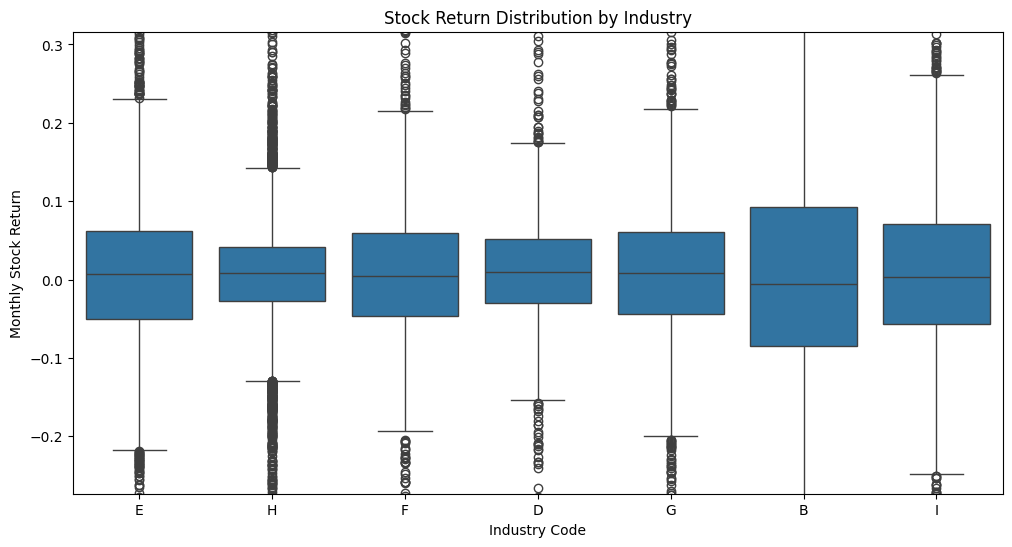

In [20]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=stock_long,
    x="Industry_Code",
    y="Return"
)

plt.ylim(lower_limit, upper_limit)

plt.title("Stock Return Distribution by Industry")
plt.xlabel("Industry Code")
plt.ylabel("Monthly Stock Return")

plt.show()

The boxplot shows how stock returns vary across industries. It helps identify differences in volatility, spread, and outliers before applying PCA, Factor Analysis, and clustering.

### 9.7 Outlier Check

This section calculates stock-level z-scores to identify unusually large positive or negative monthly returns.

In [21]:
stock_long["Return_Zscore"] = (
    stock_long
    .groupby("Stock_ID")["Return"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

stock_long["Is_Outlier"] = stock_long["Return_Zscore"].abs() > 3

stock_long.head()

,Date,Stock_ID,Return,Industry_Code,Industry_Name,Return_Zscore,Is_Outlier
0,Y2005M1,E40440,-0.033914,E,Transportation and Public Utilities,-0.237271,False
1,Y2005M2,E40440,-0.004922,E,Transportation and Public Utilities,-0.056845,False
2,Y2005M3,E40440,0.027731,E,Transportation and Public Utilities,0.146363,False
3,Y2005M4,E40440,-0.118140,E,Transportation and Public Utilities,-0.761433,False
4,Y2005M5,E40440,0.039177,E,Transportation and Public Utilities,0.217595,False


The new columns show each return’s z-score and whether it is an outlier. A return is flagged as an outlier when its absolute z-score is greater than 3.

### 9.8 Summarise Outliers by Stock

This section counts how many outlier observations each stock has based on the z-score rule.

In [22]:
outlier_summary = (
    stock_long
    .groupby(["Stock_ID", "Industry_Code", "Industry_Name"])
    .agg(
        number_of_observations=("Return", "count"),
        number_of_outliers=("Is_Outlier", "sum")
    )
    .reset_index()
)

outlier_summary["outlier_percentage"] = (
    outlier_summary["number_of_outliers"] / outlier_summary["number_of_observations"] * 100
)

outlier_summary_sorted = outlier_summary.sort_values(
    "number_of_outliers",
    ascending=False
)

outlier_summary_sorted.head(10)

,Stock_ID,Industry_Code,Industry_Name,number_of_observations,number_of_outliers,outlier_percentage
20,E80185,E,Transportation and Public Utilities,180,5,2.777778
25,E88439,E,Transportation and Public Utilities,180,5,2.777778
12,E40440,E,Transportation and Public Utilities,180,5,2.777778
53,H71563,H,"Finance, Insurance and Real Estate",180,5,2.777778
69,H85604,H,"Finance, Insurance and Real Estate",180,5,2.777778
84,I10257,I,Services,180,5,2.777778
17,E65700,E,Transportation and Public Utilities,180,4,2.222222
48,H12166,H,"Finance, Insurance and Real Estate",180,4,2.222222
38,F89617,F,Wholesale Trade,180,4,2.222222
49,H16505,H,"Finance, Insurance and Real Estate",180,4,2.222222


The table lists stocks with the highest number of outlier returns. Each stock has 180 observations, and the outlier percentage shows how often extreme returns occurred.

## 10. Principal Component Analysis

Principal Component Analysis is used to reduce the 92 stock-return variables into a smaller number of components that capture the main common patterns in the data.

The first principal component, PC1, is especially important because it is expected to capture the strongest common movement across stocks. Later, PC1 will be compared with the S&P500 market return to test whether it behaves like a market factor.

### 10.1Standardise the stock-return data

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

stock_scaled = scaler.fit_transform(stock_df)

stock_scaled_df = pd.DataFrame(
    stock_scaled,
    columns=stock_df.columns
)

stock_scaled_df.head()

,E40440,H76123,H79048,F54199,H86871,D82932,D18729,G81540,B89509,E78629,...,G66376,H12166,G11618,E43481,I87361,I88203,B79444,H85763,G66181,E88439
0,-0.237933,0.723563,-1.059376,-1.114527,0.451670,-0.569222,0.562288,-0.318055,-0.462307,0.210482,...,-0.381602,0.672495,-0.482429,-0.006619,-0.338556,0.928215,-0.231911,-1.554355,-0.785690,-0.784659
1,-0.057004,0.568089,1.370473,0.514685,-0.296597,0.603364,-0.026251,0.246455,1.006669,1.216416,...,1.199681,1.009423,-0.474381,-0.017977,-0.250936,-0.864263,0.780230,0.593332,-0.710138,0.393147
2,0.146772,-0.696877,-2.535871,-0.258836,-1.321116,0.185453,-0.541873,-0.910161,-0.440343,-0.603706,...,1.208930,-0.172270,-0.888465,-0.657432,-0.303247,-0.565648,-0.151895,-1.680472,-0.907083,0.010170
3,-0.763557,0.350789,-0.300101,1.084542,1.669436,0.219627,-1.165509,0.913694,-0.872530,-0.380617,...,0.263811,-0.193409,-0.600440,-0.508478,-0.221718,0.749806,-0.339948,-0.562797,-1.453249,-0.924248
4,0.218202,1.334897,1.590795,1.387720,0.405792,0.993253,-0.113404,0.663198,0.456861,0.477102,...,0.051957,0.527959,0.955693,0.165640,0.017229,2.147078,-0.194535,-0.616188,1.644384,0.636962


The standardised dataframe keeps the same 180 months and 92 stocks. Each stock return series is now placed on a comparable scale, preventing high-volatility stocks from dominating PCA, Factor Analysis, and clustering.

### 10.2 Fit PCA Model

This section fits PCA on the standardised stock-return data and creates principal component scores.

In [24]:
from sklearn.decomposition import PCA

pca = PCA()

pca_scores = pca.fit_transform(stock_scaled_df)

pca_scores_df = pd.DataFrame(
    pca_scores,
    columns=[f"PC{i+1}" for i in range(pca_scores.shape[1])]
)

pca_scores_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC83,PC84,PC85,PC86,PC87,PC88,PC89,PC90,PC91,PC92
0,-3.341202,1.735118,0.537537,2.293221,0.119577,-0.560410,-0.181288,0.632584,-0.019986,-0.513999,...,0.297443,-0.161639,-0.224150,0.031520,-0.052824,-0.087413,0.253610,0.073793,0.016919,-0.108781
1,1.444937,0.373650,-1.678826,1.635975,0.202473,0.418456,-0.720063,-0.040659,0.920801,-0.500720,...,-0.644884,0.497758,-0.116551,0.208179,-0.242209,-0.003396,0.163895,-0.215751,0.133824,0.209325
2,-4.410085,-2.475349,-1.022970,-0.031663,-0.168357,0.371921,-0.039419,1.040226,0.850838,-0.846080,...,0.492693,-0.300233,0.237590,-0.244006,-0.093139,-0.370479,-0.041450,-0.318498,0.208626,-0.200139
3,-3.361186,0.972697,1.028102,-0.930148,-1.016653,1.145581,0.373534,-1.081723,1.038081,-1.204191,...,0.081375,0.119688,0.547220,0.182774,0.147481,0.141314,-0.103135,0.145506,0.055157,-0.115543
4,4.481736,0.610276,1.694791,0.846028,-1.153305,-1.432372,1.225310,-0.252104,-0.336531,-1.127684,...,0.109524,-0.001602,0.131239,0.205340,-0.205235,0.105587,0.013067,0.326009,0.253551,-0.008640


The PCA score table shows the transformed data. Each row represents a month, and each column represents a principal component created from the original 92 stock returns.

### 10.3 Explained Variance

This section calculates how much variation each principal component explains.

In [25]:
explained_variance_df = pd.DataFrame({
    "Principal_Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained_Variance_Ratio": pca.explained_variance_ratio_,
    "Cumulative_Explained_Variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance_df.head(10)

,Principal_Component,Explained_Variance_Ratio,Cumulative_Explained_Variance
0,PC1,0.266231,0.266231
1,PC2,0.065967,0.332198
2,PC3,0.039813,0.372011
3,PC4,0.032348,0.404358
4,PC5,0.025477,0.429836
5,PC6,0.022469,0.452305
6,PC7,0.021797,0.474102
7,PC8,0.020115,0.494216
8,PC9,0.019207,0.513424
9,PC10,0.018837,0.532261


PC1 explains about 26.62% of the total variation, while the first 10 components explain about 53.23%. This shows that PCA reduces the 92 stock variables into fewer meaningful components.

### 10.4 Scree Plot

This plot visualises how much variance is explained by the first 10 principal components.

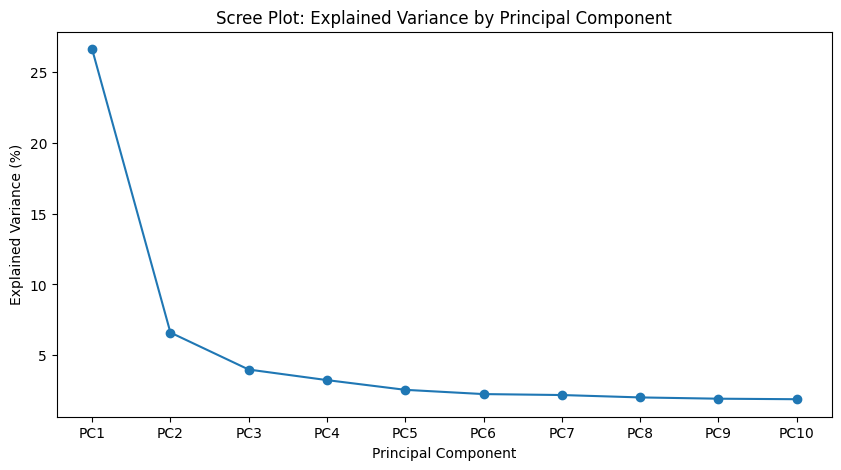

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    explained_variance_df["Principal_Component"][:10],
    explained_variance_df["Explained_Variance_Ratio"][:10] * 100,
    marker="o"
)

plt.title("Scree Plot: Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")

plt.show()

The scree plot shows that PC1 explains the largest share of variation, with a sharp drop after PC1. This suggests that the first principal component captures the strongest common movement across the stock returns.

### 10.5 PC1 and Market Return

This section combines PC1 scores with S&P500 market returns to check whether PC1 captures market-wide movement.

In [27]:
pc1_market_df = join_data[["Date", "MarketReturn"]].copy()

pc1_market_df["PC1"] = pca_scores_df["PC1"]

pc1_market_df.head()

,Date,MarketReturn,PC1
0,Y2005M1,-2.76,-3.341202
1,Y2005M2,1.89,1.444937
2,Y2005M3,-1.97,-4.410085
3,Y2005M4,-2.61,-3.361186
4,Y2005M5,3.65,4.481736


The table shows monthly market returns and PC1 scores together. This prepares the data for comparing PC1 with market movement using correlation and time-series visualisation.

### 10.6 Standardise PC1 and Market Return

This section standardises PC1 and market returns so both can be compared on the same z-score scale.

In [28]:
pc1_market_df["MarketReturn_Z"] = (
    pc1_market_df["MarketReturn"] - pc1_market_df["MarketReturn"].mean()
) / pc1_market_df["MarketReturn"].std()

pc1_market_df["PC1_Z"] = (
    pc1_market_df["PC1"] - pc1_market_df["PC1"].mean()
) / pc1_market_df["PC1"].std()

pc1_market_df.head()

,Date,MarketReturn,PC1,MarketReturn_Z,PC1_Z
0,Y2005M1,-2.76,-3.341202,-0.844726,-0.673240
1,Y2005M2,1.89,1.444937,0.285554,0.291150
2,Y2005M3,-1.97,-4.410085,-0.652700,-0.888616
3,Y2005M4,-2.61,-3.361186,-0.808265,-0.677267
4,Y2005M5,3.65,4.481736,0.713360,0.903054


The z-score columns place PC1 and market return on the same scale. This makes visual comparison easier because both series now have mean 0 and standard deviation 1.

### 10.7 Convert Date for PC1 Comparison

This section converts the original text-based date into a proper datetime format for plotting PC1 against market returns.

In [29]:
pc1_market_df["Year"] = pc1_market_df["Date"].str.extract(r"Y(\d{4})").astype(int)
pc1_market_df["Month"] = pc1_market_df["Date"].str.extract(r"M(\d{1,2})").astype(int)

pc1_market_df["Date_Formatted"] = pd.to_datetime(
    pc1_market_df["Year"].astype(str) + "-" + pc1_market_df["Month"].astype(str) + "-01"
)

pc1_market_df.head()

,Date,MarketReturn,PC1,MarketReturn_Z,PC1_Z,Year,Month,Date_Formatted
0,Y2005M1,-2.76,-3.341202,-0.844726,-0.673240,2005,1,2005-01-01
1,Y2005M2,1.89,1.444937,0.285554,0.291150,2005,2,2005-02-01
2,Y2005M3,-1.97,-4.410085,-0.652700,-0.888616,2005,3,2005-03-01
3,Y2005M4,-2.61,-3.361186,-0.808265,-0.677267,2005,4,2005-04-01
4,Y2005M5,3.65,4.481736,0.713360,0.903054,2005,5,2005-05-01


The formatted date column allows PC1 and market return to be plotted as time-series data. This prepares the dataset for visual comparison over the full sample period.

### 10.8 Plot PC1 Against Market Return

This section plots standardised PC1 and standardised S&P500 market return to visually compare their movement over time.

In [30]:

pc1_market_correlation = pc1_market_df["PC1"].corr(pc1_market_df["MarketReturn"])


if pc1_market_correlation < 0:
    pc1_market_df["PC1"] = -pc1_market_df["PC1"]
    pca_scores_df["PC1"] = -pca_scores_df["PC1"]
    pc1_market_correlation = pc1_market_df["PC1"].corr(pc1_market_df["MarketReturn"])


pc1_market_df["MarketReturn_Z"] = (
    pc1_market_df["MarketReturn"] - pc1_market_df["MarketReturn"].mean()
) / pc1_market_df["MarketReturn"].std()

pc1_market_df["PC1_Z"] = (
    pc1_market_df["PC1"] - pc1_market_df["PC1"].mean()
) / pc1_market_df["PC1"].std()


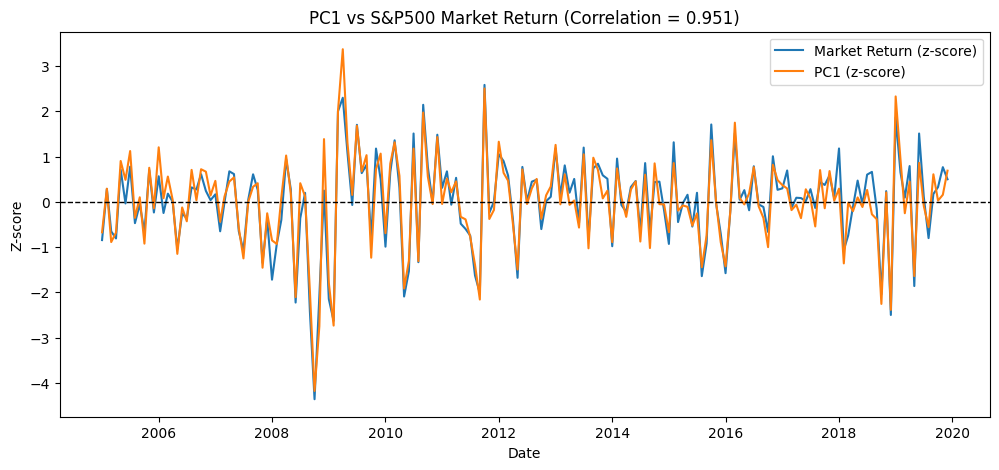

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    pc1_market_df["Date_Formatted"],
    pc1_market_df["MarketReturn_Z"],
    label="Market Return (z-score)"
)

plt.plot(
    pc1_market_df["Date_Formatted"],
    pc1_market_df["PC1_Z"],
    label="PC1 (z-score)"
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title(f"PC1 vs S&P500 Market Return (Correlation = {pc1_market_correlation:.3f})")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()

plt.show()

PC1 closely follows the S&P500 market return, with a correlation of 0.951. This supports the interpretation that PC1 captures the main market-wide movement across stocks.

### 10.9 PCA Loadings by Industry

This section calculates PCA loadings for each stock and adds industry information for industry-level interpretation.

In [32]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
    index=stock_df.columns
)

pca_loadings = pca_loadings.reset_index()
pca_loadings = pca_loadings.rename(columns={"index": "Stock_ID"})

pca_loadings["Industry_Code"] = pca_loadings["Stock_ID"].str[0]
pca_loadings["Industry_Name"] = pca_loadings["Industry_Code"].map(industry_map)

pca_loadings.head()

,Stock_ID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC85,PC86,PC87,PC88,PC89,PC90,PC91,PC92,Industry_Code,Industry_Name
0,E40440,0.087051,-0.015526,0.047339,0.082077,-0.032478,-0.114343,-0.014221,0.298098,0.008040,...,-0.010004,-0.005950,-0.031672,-0.022899,0.087883,-0.033006,-0.024903,0.030339,E,Transportation and Public Utilities
1,H76123,0.105513,-0.023741,0.154801,0.083981,-0.083523,0.193717,-0.052659,0.046391,0.163717,...,0.061049,-0.117358,-0.011427,-0.008798,0.026558,-0.066233,0.001815,-0.042472,H,"Finance, Insurance and Real Estate"
2,H79048,0.050608,0.296129,0.185898,0.056650,0.015975,-0.067458,-0.014363,-0.083801,0.056669,...,-0.042955,-0.015603,0.020283,0.000559,0.007663,0.135382,0.016054,0.005271,H,"Finance, Insurance and Real Estate"
3,F54199,0.072773,-0.079793,0.038728,-0.213807,-0.126918,-0.194575,-0.087881,-0.133975,0.034057,...,-0.052773,0.080683,0.056708,0.003591,-0.066575,0.053566,0.018156,-0.012631,F,Wholesale Trade
4,H86871,0.044862,0.334470,0.169450,0.050245,-0.018070,-0.059185,0.030284,0.006422,0.007593,...,0.189411,0.178302,0.254465,0.373128,0.180651,0.022689,-0.326115,0.025796,H,"Finance, Insurance and Real Estate"


The PCA loading table shows how strongly each stock contributes to each principal component. Adding industry information helps identify which industries have stronger exposure to the main PCA components.

### 10.10 PCA Industry Loading Summary

This section summarises PC1, PC2, and PC3 loadings by industry to understand which industries contribute most to the main principal components.

PC1 industry loadings

In [33]:
pc1_industry_loadings = (
    pca_loadings
    .groupby(["Industry_Code", "Industry_Name"])
    .agg(
        pc1_mean_loading=("PC1", "mean"),
        pc1_total_loading=("PC1", "sum"),
        number_of_stocks=("Stock_ID", "nunique")
    )
    .reset_index()
    .sort_values("pc1_mean_loading", ascending=False)
)

pc1_industry_loadings

,Industry_Code,Industry_Name,pc1_mean_loading,pc1_total_loading,number_of_stocks
5,H,"Finance, Insurance and Real Estate",0.107325,3.971039,37
4,G,Retail Trade,0.104891,0.839126,8
2,E,Transportation and Public Utilities,0.095561,1.720104,18
3,F,Wholesale Trade,0.089690,0.896896,10
1,D,Manufacturing,0.086489,0.605426,7
6,I,Services,0.078748,0.629980,8
0,B,Mining,0.075247,0.300987,4


PC2 and PC3 industry loading tables

In [34]:
pc2_industry_loadings = (
    pca_loadings
    .groupby(["Industry_Code", "Industry_Name"])
    .agg(
        pc2_mean_loading=("PC2", "mean"),
        pc2_total_loading=("PC2", "sum"),
        number_of_stocks=("Stock_ID", "nunique")
    )
    .reset_index()
    .sort_values("pc2_mean_loading", ascending=False)
)

pc2_industry_loadings

,Industry_Code,Industry_Name,pc2_mean_loading,pc2_total_loading,number_of_stocks
5,H,"Finance, Insurance and Real Estate",0.043802,1.620672,37
0,B,Mining,0.040894,0.163578,4
1,D,Manufacturing,0.013817,0.096721,7
3,F,Wholesale Trade,0.002825,0.028252,10
2,E,Transportation and Public Utilities,-0.016020,-0.288361,18
6,I,Services,-0.021220,-0.169761,8
4,G,Retail Trade,-0.034099,-0.272795,8


In [35]:
pc3_industry_loadings = (
    pca_loadings
    .groupby(["Industry_Code", "Industry_Name"])
    .agg(
        pc3_mean_loading=("PC3", "mean"),
        pc3_total_loading=("PC3", "sum"),
        number_of_stocks=("Stock_ID", "nunique")
    )
    .reset_index()
    .sort_values("pc3_mean_loading", ascending=False)
)

pc3_industry_loadings

,Industry_Code,Industry_Name,pc3_mean_loading,pc3_total_loading,number_of_stocks
4,G,Retail Trade,0.046477,0.371817,8
5,H,"Finance, Insurance and Real Estate",0.043724,1.617781,37
1,D,Manufacturing,0.014482,0.101376,7
6,I,Services,-0.003202,-0.025617,8
2,E,Transportation and Public Utilities,-0.033266,-0.598795,18
3,F,Wholesale Trade,-0.062104,-0.621044,10
0,B,Mining,-0.145761,-0.583042,4


The loading summaries show industry-level exposure to the first three principal components. Industry H has the strongest average PC1 loading, while PC2 and PC3 highlight additional industry-specific patterns.

## 11. Factor Analysis

Factor Analysis is used to identify hidden common factors that explain the co-movement among stock returns.

Unlike PCA, which summarises total variation, Factor Analysis focuses on common variation shared across stocks. This makes it useful for analysing systematic risk.

In this section, a three-factor model is fitted to the standardised stock-return matrix using varimax rotation.

### 11.1 Fit Factor Analysis Model

This section fits a three-factor model using varimax rotation to identify common factors shared across stock returns.

In [36]:
# Compatibility patch for factor_analyzer with newer scikit-learn versions

import sklearn.utils.validation as sk_validation
import factor_analyzer.factor_analyzer as fa_module

_original_check_array = sk_validation.check_array

def check_array_compat(*args, **kwargs):
    if "force_all_finite" in kwargs:
        kwargs["ensure_all_finite"] = kwargs.pop("force_all_finite")
    return _original_check_array(*args, **kwargs)

fa_module.check_array = check_array_compat

from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer(
    n_factors=3,
    rotation="varimax",
    method="ml",
    bounds=(0.05, 1)
)

fa.fit(stock_scaled_df)

print("Factor Analysis model fitted successfully")

Factor Analysis model fitted successfully


The Factor Analysis model is fitted successfully. The model will be used to extract factor loadings, uniqueness, and communality for systematic risk analysis.

### 11.2 Extract Factor Loadings

This section extracts factor loadings for each stock and adds industry information for interpretation.

In [37]:
factor_loadings = pd.DataFrame(
    fa.loadings_,
    columns=["Factor1", "Factor2", "Factor3"],
    index=stock_df.columns
)

factor_loadings = factor_loadings.reset_index()
factor_loadings = factor_loadings.rename(columns={"index": "Stock_ID"})

factor_loadings["Industry_Code"] = factor_loadings["Stock_ID"].str[0]
factor_loadings["Industry_Name"] = factor_loadings["Industry_Code"].map(industry_map)

factor_loadings.head()

,Stock_ID,Factor1,Factor2,Factor3,Industry_Code,Industry_Name
0,E40440,0.230449,0.333485,0.094621,E,Transportation and Public Utilities
1,H76123,0.210930,0.516469,0.148662,H,"Finance, Insurance and Real Estate"
2,H79048,0.104287,0.046330,0.815416,H,"Finance, Insurance and Real Estate"
3,F54199,0.202983,0.295567,-0.090237,F,Wholesale Trade
4,H86871,0.106151,-0.018416,0.923022,H,"Finance, Insurance and Real Estate"


The factor loading table shows how strongly each stock is related to Factor 1, Factor 2, and Factor 3. Industry information helps compare factor exposure across sectors.

### 11.3 Factor Loadings by Industry

This section summarises average factor loadings by industry to compare how different industries relate to the three common factors.

In [38]:
factor_industry_loadings = (
    factor_loadings
    .groupby(["Industry_Code", "Industry_Name"])
    .agg(
        factor1_mean_loading=("Factor1", "mean"),
        factor2_mean_loading=("Factor2", "mean"),
        factor3_mean_loading=("Factor3", "mean"),
        number_of_stocks=("Stock_ID", "nunique")
    )
    .reset_index()
)

factor_industry_loadings

,Industry_Code,Industry_Name,factor1_mean_loading,factor2_mean_loading,factor3_mean_loading,number_of_stocks
0,B,Mining,0.413211,0.080696,0.053132,4
1,D,Manufacturing,0.310103,0.253886,0.095760,7
2,E,Transportation and Public Utilities,0.373040,0.276721,0.027095,18
3,F,Wholesale Trade,0.389761,0.214644,0.031772,10
4,G,Retail Trade,0.301492,0.413835,0.062843,8
5,H,"Finance, Insurance and Real Estate",0.351466,0.356983,0.216253,37
6,I,Services,0.278902,0.260564,0.027779,8


The table shows industry-level exposure to Factor 1, Factor 2, and Factor 3. It helps identify which industries are more strongly connected to the common factors estimated by Factor Analysis.

### 11.4 Uniqueness and Communality

This section calculates uniqueness and communality to measure how much of each stock’s variation is explained by common factors.

In [39]:
uniqueness = fa.get_uniquenesses()
communality = 1 - uniqueness

risk_df = pd.DataFrame({
    "Stock_ID": stock_df.columns,
    "Uniqueness": uniqueness,
    "Communality": communality
})

risk_df["Industry_Code"] = risk_df["Stock_ID"].str[0]
risk_df["Industry_Name"] = risk_df["Industry_Code"].map(industry_map)

risk_df.head()

,Stock_ID,Uniqueness,Communality,Industry_Code,Industry_Name
0,E40440,0.826728,0.173272,E,Transportation and Public Utilities
1,H76123,0.666668,0.333332,H,"Finance, Insurance and Real Estate"
2,H79048,0.322075,0.677925,H,"Finance, Insurance and Real Estate"
3,F54199,0.863295,0.136705,F,Wholesale Trade
4,H86871,0.136423,0.863577,H,"Finance, Insurance and Real Estate"


Higher communality means more of a stock’s return variation is explained by common factors. Higher uniqueness means more stock-specific variation remains unexplained by the factor model.

### 11.5 Systematic Risk by Industry

This section summarises average uniqueness and communality by industry to compare systematic risk exposure across sectors.

In [40]:
industry_systematic_risk = (
    risk_df
    .groupby(["Industry_Code", "Industry_Name"])
    .agg(
        average_uniqueness=("Uniqueness", "mean"),
        average_communality=("Communality", "mean"),
        number_of_stocks=("Stock_ID", "nunique")
    )
    .reset_index()
    .sort_values("average_communality", ascending=False)
)

industry_systematic_risk

,Industry_Code,Industry_Name,average_uniqueness,average_communality,number_of_stocks
5,H,"Finance, Insurance and Real Estate",0.474606,0.525394,37
4,G,Retail Trade,0.708886,0.291114,8
2,E,Transportation and Public Utilities,0.735190,0.264810,18
0,B,Mining,0.760467,0.239533,4
3,F,Wholesale Trade,0.763718,0.236282,10
1,D,Manufacturing,0.804631,0.195369,7
6,I,Services,0.827785,0.172215,8


Industry H has the highest average communality, meaning its returns are most strongly explained by common factors. Lower communality industries have more stock-specific variation.

## 12. Stock Recommendation

This section ranks stocks using market correlation, PCA loading, factor loading, and communality to identify stocks that move closely with the market.

### 12.1 Calculate Stock Correlation with Market Return

This section calculates each stock’s correlation with the S&P500 market return.Calculate Stock Correlation with Market Return

In [41]:
stock_market_correlations = []

for stock in stock_df.columns:
    correlation = join_data[stock].corr(join_data["MarketReturn"])
    
    stock_market_correlations.append({
        "Stock_ID": stock,
        "Market_Correlation": correlation
    })

stock_market_corr_df = pd.DataFrame(stock_market_correlations)

stock_market_corr_df["Industry_Code"] = stock_market_corr_df["Stock_ID"].str[0]
stock_market_corr_df["Industry_Name"] = stock_market_corr_df["Industry_Code"].map(industry_map)

stock_market_corr_df.head()

,Stock_ID,Market_Correlation,Industry_Code,Industry_Name
0,E40440,0.376569,E,Transportation and Public Utilities
1,H76123,0.480366,H,"Finance, Insurance and Real Estate"
2,H79048,0.140633,H,"Finance, Insurance and Real Estate"
3,F54199,0.313246,F,Wholesale Trade
4,H86871,0.144882,H,"Finance, Insurance and Real Estate"


The table shows how strongly each stock moves with the market return. Higher correlation indicates stronger market sensitivity, which is useful for the stock recommendation score.

### 12.2 Combine Recommendation Metrics

This section combines market correlation, PC1 loading, Factor 1 loading, and communality into one recommendation dataset.

Combine Recommendation Metrics

In [42]:
recommendation_df = (
    stock_market_corr_df
    .merge(
        pca_loadings[["Stock_ID", "PC1"]],
        on="Stock_ID",
        how="left"
    )
    .merge(
        factor_loadings[["Stock_ID", "Factor1"]],
        on="Stock_ID",
        how="left"
    )
    .merge(
        risk_df[["Stock_ID", "Communality"]],
        on="Stock_ID",
        how="left"
    )
)

recommendation_df.head()

,Stock_ID,Market_Correlation,Industry_Code,Industry_Name,PC1,Factor1,Communality
0,E40440,0.376569,E,Transportation and Public Utilities,0.087051,0.230449,0.173272
1,H76123,0.480366,H,"Finance, Insurance and Real Estate",0.105513,0.210930,0.333332
2,H79048,0.140633,H,"Finance, Insurance and Real Estate",0.050608,0.104287,0.677925
3,F54199,0.313246,F,Wholesale Trade,0.072773,0.202983,0.136705
4,H86871,0.144882,H,"Finance, Insurance and Real Estate",0.044862,0.106151,0.863577


The combined table brings together the main metrics used for stock ranking. These metrics represent market sensitivity, PCA contribution, factor exposure, and systematic risk explained by common factors.

### 12.3 Create Recommendation Score

This section scales the ranking metrics and calculates an overall recommendation score for each stock.

In [43]:
ranking_metrics = ["Market_Correlation", "PC1", "Factor1", "Communality"]

recommendation_ranked = recommendation_df.copy()

for metric in ranking_metrics:
    min_value = recommendation_ranked[metric].min()
    max_value = recommendation_ranked[metric].max()
    
    recommendation_ranked[metric + "_Scaled"] = (
        (recommendation_ranked[metric] - min_value) / (max_value - min_value)
    )

recommendation_ranked["Recommendation_Score"] = recommendation_ranked[
    [metric + "_Scaled" for metric in ranking_metrics]
].mean(axis=1)

recommendation_ranked = recommendation_ranked.sort_values(
    "Recommendation_Score",
    ascending=False
)

recommendation_ranked.head(10)

,Stock_ID,Market_Correlation,Industry_Code,Industry_Name,PC1,Factor1,Communality,Market_Correlation_Scaled,PC1_Scaled,Factor1_Scaled,Communality_Scaled,Recommendation_Score
49,H90005,0.953810,H,"Finance, Insurance and Real Estate",0.195843,0.708401,0.948400,1.000000,1.000000,0.877330,1.000000,0.969333
18,H70797,0.904647,H,"Finance, Insurance and Real Estate",0.182982,0.713726,0.848791,0.950018,0.933739,0.883496,0.889325,0.914144
48,H90105,0.859807,H,"Finance, Insurance and Real Estate",0.173776,0.805749,0.834909,0.904431,0.886310,0.990029,0.873901,0.913667
20,H88301,0.868027,H,"Finance, Insurance and Real Estate",0.171451,0.814362,0.819611,0.912787,0.874328,1.000000,0.856903,0.911004
78,H75938,0.806063,H,"Finance, Insurance and Real Estate",0.164716,0.812175,0.778557,0.849790,0.839629,0.997469,0.811288,0.874544
63,H89895,0.844946,H,"Finance, Insurance and Real Estate",0.171058,0.460109,0.767988,0.889322,0.872303,0.589884,0.799544,0.787763
29,H88297,0.839298,H,"Finance, Insurance and Real Estate",0.164648,0.407933,0.844535,0.883579,0.839277,0.529481,0.884596,0.784233
26,H85593,0.755032,H,"Finance, Insurance and Real Estate",0.160785,0.637060,0.646283,0.797908,0.819376,0.794740,0.664318,0.769085
62,H83223,0.696325,H,"Finance, Insurance and Real Estate",0.148270,0.710614,0.593238,0.738223,0.754896,0.879892,0.605380,0.744598
56,E49680,0.769560,E,Transportation and Public Utilities,0.149381,0.629121,0.559324,0.812679,0.760618,0.785549,0.567698,0.731636


The recommendation score combines market correlation, PC1 loading, Factor 1 loading, and communality. Higher scores indicate stocks with stronger market sensitivity and stronger common-factor exposure.

### 12.4 Select Top Five Stocks

This section selects the top five stocks based on the final recommendation score.

In [44]:
top_five_stocks = recommendation_ranked.head(5)

top_five_stocks[
    [
        "Stock_ID",
        "Industry_Code",
        "Industry_Name",
        "Market_Correlation",
        "PC1",
        "Factor1",
        "Communality",
        "Recommendation_Score"
    ]
]

,Stock_ID,Industry_Code,Industry_Name,Market_Correlation,PC1,Factor1,Communality,Recommendation_Score
49,H90005,H,"Finance, Insurance and Real Estate",0.953810,0.195843,0.708401,0.948400,0.969333
18,H70797,H,"Finance, Insurance and Real Estate",0.904647,0.182982,0.713726,0.848791,0.914144
48,H90105,H,"Finance, Insurance and Real Estate",0.859807,0.173776,0.805749,0.834909,0.913667
20,H88301,H,"Finance, Insurance and Real Estate",0.868027,0.171451,0.814362,0.819611,0.911004
78,H75938,H,"Finance, Insurance and Real Estate",0.806063,0.164716,0.812175,0.778557,0.874544


The top five recommended stocks all belong to Industry H, Finance, Insurance and Real Estate. These stocks have high market correlation, strong PC1 loading, strong Factor 1 exposure, and high communality.

## 13. K-means Clustering

### 13.1 Prepare Data for Clustering

The original stock-return matrix has months as rows and stocks as columns. Since the aim is to cluster stocks, the matrix is transposed so that each row represents one stock and each column represents one monthly return observation.

In [45]:
stock_cluster_data = stock_scaled_df.T

print("Clustering data shape:", stock_cluster_data.shape)

stock_cluster_data.head()

Clustering data shape: (92, 180)


,0,1,2,3,4,5,6,7,8,9,...,170,171,172,173,174,175,176,177,178,179
E40440,-0.237933,-0.057004,0.146772,-0.763557,0.218202,-0.643369,0.605940,-0.211572,-1.786667,0.277956,...,1.250361,-0.578759,-1.009701,0.458280,3.209854,-1.237628,-0.031854,-2.366529,0.214420,2.797884
H76123,0.723563,0.568089,-0.696877,0.350789,1.334897,0.366652,-0.004576,-0.738659,-1.646219,0.568941,...,0.619352,0.344121,-0.631753,0.853306,1.137463,-0.635201,-0.454739,0.834976,0.254009,0.446470
H79048,-1.059376,1.370473,-2.535871,-0.300101,1.590795,0.400560,-0.709419,0.540985,-0.844942,-0.785222,...,0.483954,0.283180,0.397870,0.391144,0.684399,0.283240,-0.100044,0.123865,0.011387,0.055834
F54199,-1.114527,0.514685,-0.258836,1.084542,1.387720,1.440304,2.288785,-1.572502,-0.505316,0.016509,...,-0.039157,-0.097607,-0.200485,-0.368117,0.787471,0.643841,-0.179140,0.669511,-0.411188,-0.122966
H86871,0.451670,-0.296597,-1.321116,1.669436,0.405792,0.437422,0.657661,-0.345884,-0.355741,-0.319936,...,1.209580,-0.058547,0.675933,0.343301,0.536701,0.241411,-0.020715,-0.451490,0.220959,-0.020193


The clustering dataset has 92 rows and 180 columns. Each row represents one stock, and each column represents one monthly standardised return observation.

### 13.2 Choosing the Number of Clusters using the Elbow Method

K-means requires the number of clusters to be specified in advance. The elbow method is used to compare different values of `k`.

The method calculates within-cluster sum of squares for different cluster numbers. A suitable `k` is often chosen where the improvement starts to slow down, forming an "elbow" in the plot.

In [46]:
from sklearn.cluster import KMeans

In [47]:


wcss = []

k_values = range(1, 11)

for k in k_values:
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans_model.fit(stock_cluster_data)
    wcss.append(kmeans_model.inertia_)

wcss

  File "c:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
            

[12673.462957469159,
 11794.964446227545,
 11299.512791518333,
 10991.766771004666,
 10621.86144658443,
 10469.224238816661,
 10163.737635550518,
 10114.014176754648,
 9805.305984478302,
 9559.777212062669]

Elbow Plot

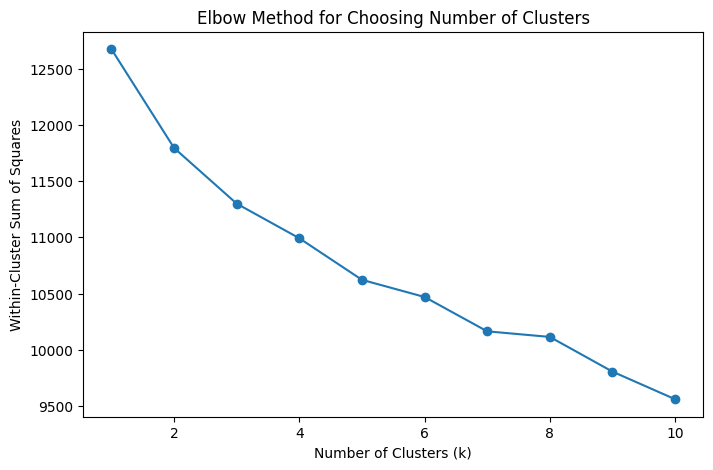

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    wcss,
    marker="o"
)

plt.title("Elbow Method for Choosing Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")

plt.show()

The elbow plot compares within-cluster sum of squares for different cluster numbers. The curve gradually decreases as `k` increases, and `k = 3` is selected to keep the clustering simple and interpretable.

### 13.3 Fit Final K-means Model

This section fits the final K-means model using three clusters and assigns each stock to a cluster.

In [49]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(stock_cluster_data)

cluster_results = pd.DataFrame({
    "Stock_ID": stock_cluster_data.index,
    "Cluster": cluster_labels
})

cluster_results["Industry_Code"] = cluster_results["Stock_ID"].str[0]
cluster_results["Industry_Name"] = cluster_results["Industry_Code"].map(industry_map)

cluster_results.head()

,Stock_ID,Cluster,Industry_Code,Industry_Name
0,E40440,0,E,Transportation and Public Utilities
1,H76123,0,H,"Finance, Insurance and Real Estate"
2,H79048,2,H,"Finance, Insurance and Real Estate"
3,F54199,1,F,Wholesale Trade
4,H86871,2,H,"Finance, Insurance and Real Estate"


### 13.4 K-means Cluster Summary

This section summarises the size of each K-means cluster and shows the industry composition within each cluster.

In [50]:
cluster_size_summary = (
    cluster_results
    .groupby("Cluster")
    .agg(number_of_stocks=("Stock_ID", "nunique"))
    .reset_index()
)

cluster_size_summary

,Cluster,number_of_stocks
0,0,21
1,1,64
2,2,7


In [51]:
cluster_industry_summary = (
    cluster_results
    .groupby(["Cluster", "Industry_Code", "Industry_Name"])
    .agg(number_of_stocks=("Stock_ID", "nunique"))
    .reset_index()
    .sort_values(["Cluster", "number_of_stocks"], ascending=[True, False])
)

cluster_industry_summary

,Cluster,Industry_Code,Industry_Name,number_of_stocks
2,0,H,"Finance, Insurance and Real Estate",13
0,0,E,Transportation and Public Utilities,4
1,0,G,Retail Trade,4
8,1,H,"Finance, Insurance and Real Estate",17
5,1,E,Transportation and Public Utilities,14
6,1,F,Wholesale Trade,10
9,1,I,Services,8
4,1,D,Manufacturing,7
3,1,B,Mining,4
7,1,G,Retail Trade,4


The cluster summary shows that Cluster 1 contains the largest number of stocks, while Cluster 2 is the smallest group. The industry summary helps identify which sectors dominate each cluster.

### 13.5 Recommended Stocks by K-means Cluster

This section checks which K-means cluster contains the top five recommended stocks.

In [52]:
top_five_with_clusters = top_five_stocks.merge(
    cluster_results[["Stock_ID", "Cluster"]],
    on="Stock_ID",
    how="left"
)

top_five_with_clusters[
    [
        "Stock_ID",
        "Industry_Code",
        "Industry_Name",
        "Market_Correlation",
        "PC1",
        "Factor1",
        "Communality",
        "Recommendation_Score",
        "Cluster"
    ]
]

,Stock_ID,Industry_Code,Industry_Name,Market_Correlation,PC1,Factor1,Communality,Recommendation_Score,Cluster
0,H90005,H,"Finance, Insurance and Real Estate",0.953810,0.195843,0.708401,0.948400,0.969333,1
1,H70797,H,"Finance, Insurance and Real Estate",0.904647,0.182982,0.713726,0.848791,0.914144,1
2,H90105,H,"Finance, Insurance and Real Estate",0.859807,0.173776,0.805749,0.834909,0.913667,1
3,H88301,H,"Finance, Insurance and Real Estate",0.868027,0.171451,0.814362,0.819611,0.911004,1
4,H75938,H,"Finance, Insurance and Real Estate",0.806063,0.164716,0.812175,0.778557,0.874544,1


The cluster comparison shows that all five recommended stocks belong to Cluster 1. This means K-means grouped these stocks into the same return-behaviour category based on their standardised monthly return patterns.

This provides additional support for the recommendation because the selected stocks not only have high market correlation, strong PC1 loading, strong Factor 1 loading, and high communality, but they also share similar return behaviour according to the clustering model.

Since all recommended stocks are from Industry H and belong to the same cluster, the result is consistent with the earlier PCA and Factor Analysis findings that Finance, Insurance and Real Estate stocks are strongly connected to common market movement in this dataset.

## 14. Hierarchical Clustering

Hierarchical clustering is used as an additional unsupervised learning method to examine stock similarity.

Unlike K-means, which requires the number of clusters to be selected in advance, hierarchical clustering builds a tree-like structure called a dendrogram. This helps visualise how stocks are grouped based on similarity in their standardised monthly return patterns.

### 14.1 Prepare Data for Hierarchical Clustering

This section reuses the transposed standardised stock-return matrix, where each row represents one stock and each column represents one monthly return observation.Prepare data

In [53]:
stock_cluster_data = stock_scaled_df.T

Create linkage matrix

In [54]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(
    stock_cluster_data,
    method="ward"
)

linked[:5]

array([[18.        , 49.        ,  6.51106308,  2.        ],
       [ 4.        , 43.        ,  7.01746545,  2.        ],
       [48.        , 78.        ,  7.368557  ,  2.        ],
       [20.        , 92.        ,  7.96220451,  3.        ],
       [29.        , 63.        ,  8.28655213,  2.        ]])

The data is prepared in stock-level format for hierarchical clustering. This allows the model to group stocks based on similarity in their monthly return patterns.

Plot dendrogram

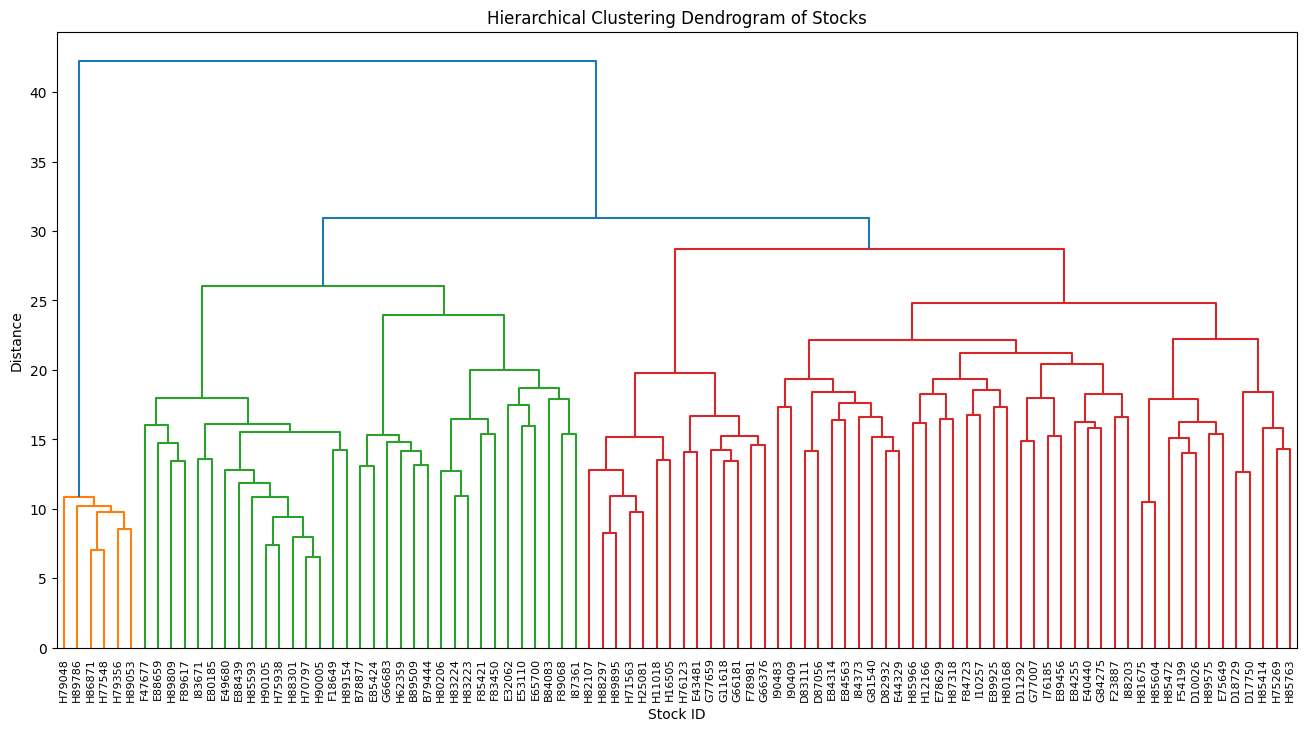

In [55]:
plt.figure(figsize=(16, 8))

dendrogram(
    linked,
    labels=stock_cluster_data.index,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Hierarchical Clustering Dendrogram of Stocks")
plt.xlabel("Stock ID")
plt.ylabel("Distance")

plt.show()

The dendrogram shows how stocks are grouped based on similarity in their standardised return patterns. Stocks that merge at lower distances have more similar return behaviour, while stocks that merge at higher distances are more different.

Because the dataset contains 92 stocks, the full dendrogram is dense, but it provides a useful visual check of stock similarity and cluster structure.

### 14.2 Create Hierarchical Cluster Labels

To compare hierarchical clustering with K-means, the dendrogram is cut into three clusters. This creates a cluster label for each stock.

In [56]:
from scipy.cluster.hierarchy import fcluster

hierarchical_labels = fcluster(
    linked,
    t=3,
    criterion="maxclust"
)

hierarchical_results = pd.DataFrame({
    "Stock_ID": stock_cluster_data.index,
    "Hierarchical_Cluster": hierarchical_labels
})

hierarchical_results["Industry_Code"] = hierarchical_results["Stock_ID"].str[0]
hierarchical_results["Industry_Name"] = hierarchical_results["Industry_Code"].map(industry_map)

hierarchical_results.head()

,Stock_ID,Hierarchical_Cluster,Industry_Code,Industry_Name
0,E40440,3,E,Transportation and Public Utilities
1,H76123,3,H,"Finance, Insurance and Real Estate"
2,H79048,1,H,"Finance, Insurance and Real Estate"
3,F54199,3,F,Wholesale Trade
4,H86871,1,H,"Finance, Insurance and Real Estate"


The hierarchical clustering labels assign each stock to one of three clusters. Industry information is added so the hierarchical clusters can be compared with K-means results.

Summarise hierarchical clusters

In [57]:
hierarchical_cluster_size = (
    hierarchical_results
    .groupby("Hierarchical_Cluster")
    .agg(number_of_stocks=("Stock_ID", "nunique"))
    .reset_index()
)

hierarchical_cluster_size

,Hierarchical_Cluster,number_of_stocks
0,1,6
1,2,33
2,3,53


### 14.3 Hierarchical Cluster Industry Summary

This section summarises the industry composition of each hierarchical cluster.

In [58]:
hierarchical_industry_summary = (
    hierarchical_results
    .groupby(["Hierarchical_Cluster", "Industry_Code", "Industry_Name"])
    .agg(number_of_stocks=("Stock_ID", "nunique"))
    .reset_index()
    .sort_values(["Hierarchical_Cluster", "number_of_stocks"], ascending=[True, False])
)

hierarchical_industry_summary

,Hierarchical_Cluster,Industry_Code,Industry_Name,number_of_stocks
0,1,H,"Finance, Insurance and Real Estate",6
5,2,H,"Finance, Insurance and Real Estate",12
2,2,E,Transportation and Public Utilities,8
3,2,F,Wholesale Trade,6
1,2,B,Mining,4
6,2,I,Services,2
4,2,G,Retail Trade,1
11,3,H,"Finance, Insurance and Real Estate",19
8,3,E,Transportation and Public Utilities,10
7,3,D,Manufacturing,7


The table shows which industries are represented in each hierarchical cluster. Finance, Insurance and Real Estate appears strongly across the clusters, while other industries are distributed based on return-pattern similarity.

### 14.4 Compare K-means and Hierarchical Clusters

This section compares each stock’s K-means cluster with its hierarchical cluster assignment.Compare K-means and hierarchical clusters

In [59]:
cluster_comparison = cluster_results.merge(
    hierarchical_results[["Stock_ID", "Hierarchical_Cluster"]],
    on="Stock_ID",
    how="left"
)

cluster_comparison.head()

,Stock_ID,Cluster,Industry_Code,Industry_Name,Hierarchical_Cluster
0,E40440,0,E,Transportation and Public Utilities,3
1,H76123,0,H,"Finance, Insurance and Real Estate",3
2,H79048,2,H,"Finance, Insurance and Real Estate",1
3,F54199,1,F,Wholesale Trade,3
4,H86871,2,H,"Finance, Insurance and Real Estate",1


The comparison table shows how each stock is grouped by both clustering methods. This helps evaluate whether the two methods produce similar stock-grouping patterns.

In [60]:
cluster_cross_tab = pd.crosstab(
    cluster_comparison["Cluster"],
    cluster_comparison["Hierarchical_Cluster"]
)

cluster_cross_tab

Hierarchical_Cluster,1,2,3
Cluster,,,
0,0,1,20
1,0,31,33
2,6,1,0


The cross-tabulation compares K-means clusters with hierarchical clusters. This helps assess whether both clustering methods identify similar stock groupings.

The cluster numbers do not need to match exactly because the two algorithms use different approaches. The important point is whether stocks from one method are concentrated in similar groups under the other method.

The hierarchical clustering results create one small cluster, one medium cluster, and one large cluster. This structure is broadly consistent with the K-means result, where one large cluster also contained most stocks.

The cross-tabulation shows that K-means Cluster 2 mostly corresponds to Hierarchical Cluster 1, indicating that both methods identify a similar small specialised group of stocks. K-means Cluster 0 mostly corresponds to Hierarchical Cluster 3, suggesting consistency between the two clustering approaches for that group.

K-means Cluster 1 is split across Hierarchical Clusters 2 and 3, which is expected because it is the largest and most diverse K-means cluster. Overall, hierarchical clustering supports the presence of meaningful stock-return behaviour groups in the dataset.

## 15. Gaussian Mixture Model Clustering

Gaussian Mixture Model clustering is used as a probabilistic clustering method. Unlike K-means, which assigns each stock to one cluster using distance from cluster centres, GMM estimates the probability that a stock belongs to each cluster.

This is useful for financial return data because stocks may not always belong clearly to one behaviour group. Some stocks may share characteristics with multiple clusters.

### 15.1 Fit Gaussian Mixture Model

A Gaussian Mixture Model with three components is fitted using the same transposed standardised stock-return matrix used for K-means and hierarchical clustering.

In [61]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    random_state=42,
    covariance_type="full"
)

gmm_labels = gmm.fit_predict(stock_cluster_data)

gmm_results = pd.DataFrame({
    "Stock_ID": stock_cluster_data.index,
    "GMM_Cluster": gmm_labels
})

gmm_results["Industry_Code"] = gmm_results["Stock_ID"].str[0]
gmm_results["Industry_Name"] = gmm_results["Industry_Code"].map(industry_map)

gmm_results.head()

,Stock_ID,GMM_Cluster,Industry_Code,Industry_Name
0,E40440,0,E,Transportation and Public Utilities
1,H76123,0,H,"Finance, Insurance and Real Estate"
2,H79048,2,H,"Finance, Insurance and Real Estate"
3,F54199,1,F,Wholesale Trade
4,H86871,2,H,"Finance, Insurance and Real Estate"


The GMM model assigns each stock to one of three probabilistic clusters. Industry information is added to help compare GMM results with K-means and hierarchical clustering.

### 15.2 GMM Cluster Membership Probabilities

GMM provides probabilities for each stock's membership in each cluster. This helps identify stocks that clearly belong to one cluster and stocks that have mixed behaviour across clusters.

In [62]:
gmm_probabilities = gmm.predict_proba(stock_cluster_data)

gmm_probability_df = pd.DataFrame(
    gmm_probabilities,
    columns=["GMM_Prob_Cluster_0", "GMM_Prob_Cluster_1", "GMM_Prob_Cluster_2"]
)

gmm_probability_df["Stock_ID"] = stock_cluster_data.index

gmm_results = gmm_results.merge(
    gmm_probability_df,
    on="Stock_ID",
    how="left"
)

gmm_results.head()

,Stock_ID,GMM_Cluster,Industry_Code,Industry_Name,GMM_Prob_Cluster_0,GMM_Prob_Cluster_1,GMM_Prob_Cluster_2
0,E40440,0,E,Transportation and Public Utilities,1.0,0.0,0.0
1,H76123,0,H,"Finance, Insurance and Real Estate",1.0,0.0,0.0
2,H79048,2,H,"Finance, Insurance and Real Estate",0.0,0.0,1.0
3,F54199,1,F,Wholesale Trade,0.0,1.0,0.0
4,H86871,2,H,"Finance, Insurance and Real Estate",0.0,0.0,1.0


The probability table shows each stock’s likelihood of belonging to each GMM cluster. Most stocks have a clear highest probability, meaning the GMM assigns them strongly to one cluster.

Summarise GMM clusters

In [63]:
gmm_cluster_size = (
    gmm_results
    .groupby("GMM_Cluster")
    .agg(number_of_stocks=("Stock_ID", "nunique"))
    .reset_index()
)

gmm_cluster_size

,GMM_Cluster,number_of_stocks
0,0,21
1,1,64
2,2,7


### 15.3 GMM Cluster Industry Summary

This section summarises the industry composition of each Gaussian Mixture Model cluster.

In [64]:
gmm_industry_summary = (
    gmm_results
    .groupby(["GMM_Cluster", "Industry_Code", "Industry_Name"])
    .agg(number_of_stocks=("Stock_ID", "nunique"))
    .reset_index()
    .sort_values(["GMM_Cluster", "number_of_stocks"], ascending=[True, False])
)

gmm_industry_summary

,GMM_Cluster,Industry_Code,Industry_Name,number_of_stocks
2,0,H,"Finance, Insurance and Real Estate",13
0,0,E,Transportation and Public Utilities,4
1,0,G,Retail Trade,4
8,1,H,"Finance, Insurance and Real Estate",17
5,1,E,Transportation and Public Utilities,14
6,1,F,Wholesale Trade,10
9,1,I,Services,8
4,1,D,Manufacturing,7
3,1,B,Mining,4
7,1,G,Retail Trade,4


The GMM cluster summaries show how stocks are distributed across probabilistic clusters and which industries are represented in each cluster. This helps compare GMM with K-means and hierarchical clustering.

### 15.4 Compare GMM with K-means

GMM cluster labels are compared with K-means cluster labels to check whether the two clustering methods identify similar stock groups.

In [65]:
gmm_kmeans_comparison = cluster_results.merge(
    gmm_results[["Stock_ID", "GMM_Cluster"]],
    on="Stock_ID",
    how="left"
)

gmm_kmeans_cross_tab = pd.crosstab(
    gmm_kmeans_comparison["Cluster"],
    gmm_kmeans_comparison["GMM_Cluster"]
)

gmm_kmeans_cross_tab

GMM_Cluster,0,1,2
Cluster,,,
0,21,0,0
1,0,64,0
2,0,0,7


The cross-tabulation shows that GMM and K-means assign stocks to the same three cluster groups. This indicates strong consistency between the two clustering methods.

### 15.5 Check Recommended Stocks in GMM Clusters

This section checks which GMM cluster contains the top five recommended stocks and reviews their cluster membership probabilities.Check top five recommended stocks in GMM clusters

In [66]:
top_five_gmm_summary = top_five_stocks.merge(
    gmm_results[
        [
            "Stock_ID",
            "GMM_Cluster",
            "GMM_Prob_Cluster_0",
            "GMM_Prob_Cluster_1",
            "GMM_Prob_Cluster_2"
        ]
    ],
    on="Stock_ID",
    how="left"
)

top_five_gmm_summary[
    [
        "Stock_ID",
        "Industry_Code",
        "Industry_Name",
        "Market_Correlation",
        "Communality",
        "Recommendation_Score",
        "GMM_Cluster",
        "GMM_Prob_Cluster_0",
        "GMM_Prob_Cluster_1",
        "GMM_Prob_Cluster_2"
    ]
]

,Stock_ID,Industry_Code,Industry_Name,Market_Correlation,Communality,Recommendation_Score,GMM_Cluster,GMM_Prob_Cluster_0,GMM_Prob_Cluster_1,GMM_Prob_Cluster_2
0,H90005,H,"Finance, Insurance and Real Estate",0.953810,0.948400,0.969333,1,0.0,1.0,0.0
1,H70797,H,"Finance, Insurance and Real Estate",0.904647,0.848791,0.914144,1,0.0,1.0,0.0
2,H90105,H,"Finance, Insurance and Real Estate",0.859807,0.834909,0.913667,1,0.0,1.0,0.0
3,H88301,H,"Finance, Insurance and Real Estate",0.868027,0.819611,0.911004,1,0.0,1.0,0.0
4,H75938,H,"Finance, Insurance and Real Estate",0.806063,0.778557,0.874544,1,0.0,1.0,0.0


The top five recommended stocks are compared with the GMM clustering results. This provides a probabilistic check of whether the recommended stocks belong to the same or similar return-behaviour group.

The GMM clustering result produces the same cluster size pattern as K-means: 21 stocks in Cluster 0, 64 stocks in Cluster 1, and 7 stocks in Cluster 2.

The cross-tabulation shows a perfect match between K-means clusters and GMM clusters. This indicates that both distance-based clustering and probabilistic clustering identify the same stock-return behaviour groups in this dataset.

This consistency strengthens confidence that the clustering structure is meaningful rather than being an artefact of a single clustering algorithm.

All five recommended stocks belong to GMM Cluster 1. This matches the earlier K-means result, where all five recommended stocks also belonged to Cluster 1.

This consistency provides additional support for the recommendation. The selected stocks not only score highly on market correlation, PC1 loading, Factor 1 loading, and communality, but are also grouped together by both K-means and Gaussian Mixture Model clustering.

This suggests that the recommended stocks share similar market-sensitive return behaviour.

## 16. Multidimensional Scaling

Multidimensional Scaling is used to visualise stock similarity in two dimensions.

The method takes high-dimensional stock-return patterns and places each stock on a 2D map. Stocks that are close together on the map have similar return behaviour, while stocks that are far apart behave more differently.

This provides a visual complement to K-means, hierarchical clustering, and GMM clustering.

### 16.1 Fit the MDS Model

The MDS model is fitted using the same transposed standardised stock-return matrix used for clustering. Each row represents one stock and each column represents one monthly return observation.

In [67]:
from sklearn.manifold import MDS

mds = MDS(
    n_components=2,
    random_state=42,
    dissimilarity="euclidean",
    normalized_stress="auto"
)

mds_coordinates = mds.fit_transform(stock_cluster_data)

mds_df = pd.DataFrame(
    mds_coordinates,
    columns=["MDS1", "MDS2"]
)

mds_df["Stock_ID"] = stock_cluster_data.index
mds_df["Industry_Code"] = mds_df["Stock_ID"].str[0]
mds_df["Industry_Name"] = mds_df["Industry_Code"].map(industry_map)

mds_df = mds_df.merge(
    cluster_results[["Stock_ID", "Cluster"]],
    on="Stock_ID",
    how="left"
)

mds_df.head()

,MDS1,MDS2,Stock_ID,Industry_Code,Industry_Name,Cluster
0,0.797941,10.699086,E40440,E,Transportation and Public Utilities,0
1,8.984946,-5.070963,H76123,H,"Finance, Insurance and Real Estate",0
2,3.624293,13.613763,H79048,H,"Finance, Insurance and Real Estate",2
3,-12.488294,-4.698017,F54199,F,Wholesale Trade,1
4,5.653536,13.094521,H86871,H,"Finance, Insurance and Real Estate",2


The MDS model converts each stock's 180-month standardised return pattern into two coordinates: `MDS1` and `MDS2`.

These coordinates are not financial variables by themselves. They are used only for visualising relative similarity between stocks.

### 16.2 MDS Map by K-means Cluster

The MDS coordinates are plotted and coloured by K-means cluster. This helps visually assess whether the clusters identified by K-means are separated in the two-dimensional similarity map.

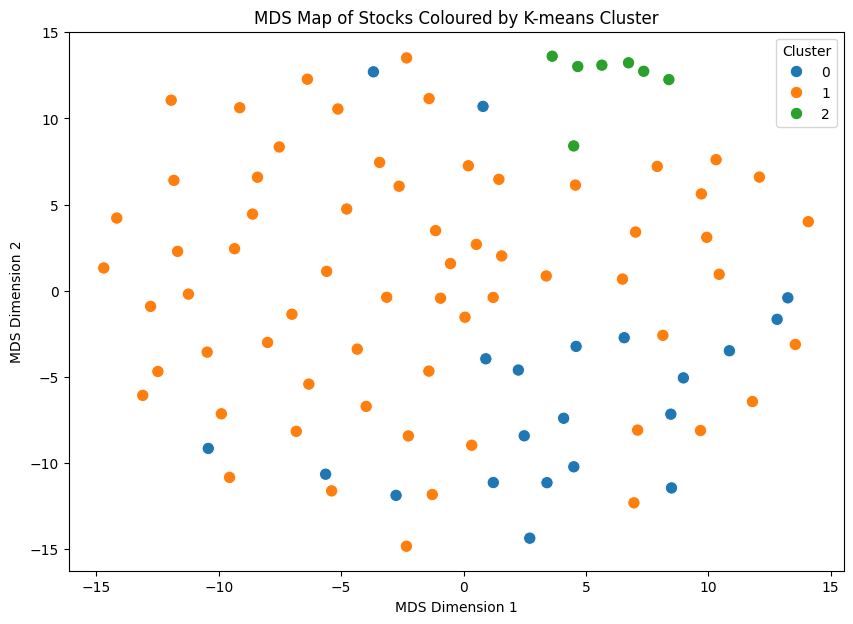

In [68]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=mds_df,
    x="MDS1",
    y="MDS2",
    hue="Cluster",
    palette="tab10",
    s=80
)

plt.title("MDS Map of Stocks Coloured by K-means Cluster")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.legend(title="Cluster")

plt.show()

The MDS plot provides a two-dimensional visualisation of stock similarity. Stocks that are positioned close together have more similar standardised return patterns, while stocks farther apart behave more differently.

The plot coloured by K-means cluster helps visually validate whether the clusters occupy different regions of the similarity map.

### 16.3 MDS Map by Industry

The same MDS coordinates are plotted by industry code to examine whether stocks from similar industries appear close together in the similarity map.

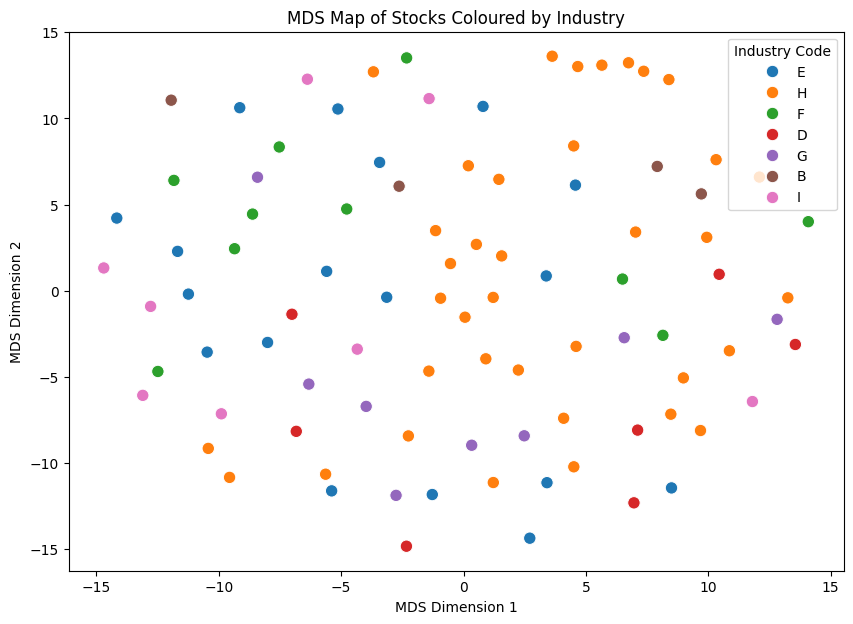

In [69]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=mds_df,
    x="MDS1",
    y="MDS2",
    hue="Industry_Code",
    palette="tab10",
    s=80
)

plt.title("MDS Map of Stocks Coloured by Industry")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.legend(title="Industry Code")

plt.show()

The MDS plot coloured by industry shows whether stocks from the same industry tend to appear close together. If several stocks from the same industry occupy nearby positions, this suggests that industry membership is related to return behaviour.

However, overlap between industries is expected because stock returns are also influenced by broad market-wide factors.

### 16.4 Highlight Recommended Stocks on the MDS Map

The five recommended stocks are highlighted on the MDS map to examine whether they are located close together in the similarity space.

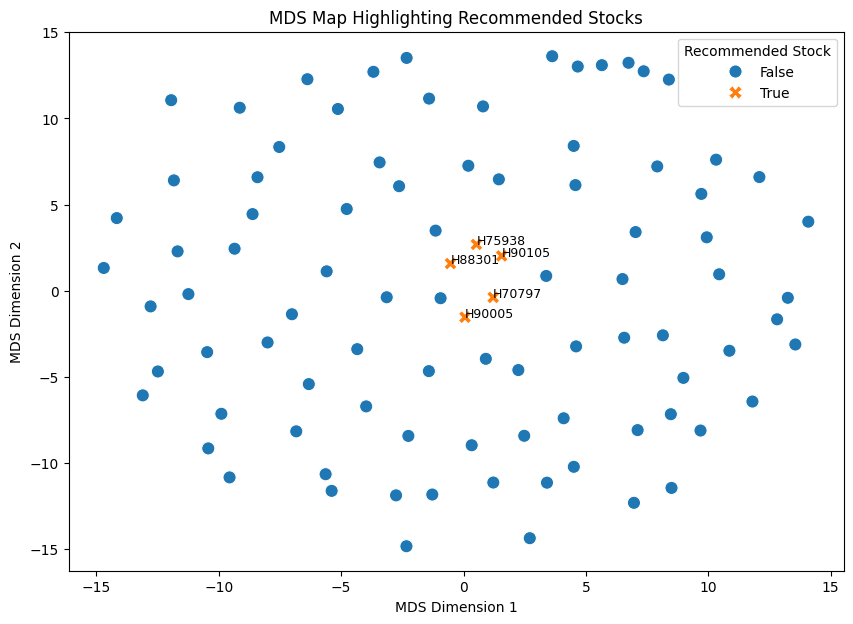

In [70]:
recommended_stock_ids = top_five_stocks["Stock_ID"].tolist()

mds_df["Recommended"] = mds_df["Stock_ID"].isin(recommended_stock_ids)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=mds_df,
    x="MDS1",
    y="MDS2",
    hue="Recommended",
    style="Recommended",
    s=90
)

for _, row in mds_df[mds_df["Recommended"]].iterrows():
    plt.text(
        row["MDS1"],
        row["MDS2"],
        row["Stock_ID"],
        fontsize=9
    )

plt.title("MDS Map Highlighting Recommended Stocks")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.legend(title="Recommended Stock")

plt.show()

The MDS map highlights the five recommended stocks. If the recommended stocks appear near each other, it supports the idea that they share similar return behaviour.

This visual evidence complements the ranking approach based on market correlation, PC1 loading, Factor 1 loading, and communality.

The MDS map highlighting the recommended stocks shows that the five selected stocks are located close to each other in the similarity space. This indicates that the recommended stocks share similar standardised return patterns.

This supports the earlier recommendation results, where these stocks were selected based on market correlation, PC1 loading, Factor 1 loading, communality, and clustering behaviour.

## 17. Correlation Analysis

Correlation analysis is used to measure how strongly stock returns move together with the market and with each other.

This section examines:

1. Stock-level correlation with the S&P500 market return.
2. Average market correlation by industry.
3. Stock-to-stock correlation structure.
4. Correlation behaviour of the recommended stocks.

### 17.1 Average Market Correlation by Industry

Each stock's monthly return is correlated with the S&P500 market return. The average correlation is then calculated by industry to understand which industries move more closely with the overall market.

In [71]:
industry_market_corr_summary = (
    stock_market_corr_df
    .groupby(["Industry_Code", "Industry_Name"])
    .agg(
        average_market_correlation=("Market_Correlation", "mean"),
        max_market_correlation=("Market_Correlation", "max"),
        min_market_correlation=("Market_Correlation", "min"),
        number_of_stocks=("Stock_ID", "nunique")
    )
    .reset_index()
    .sort_values("average_market_correlation", ascending=False)
)

industry_market_corr_summary

,Industry_Code,Industry_Name,average_market_correlation,max_market_correlation,min_market_correlation,number_of_stocks
5,H,"Finance, Insurance and Real Estate",0.493947,0.953810,0.078385,37
4,G,Retail Trade,0.483277,0.598112,0.381154,8
2,E,Transportation and Public Utilities,0.448634,0.769560,0.228476,18
3,F,Wholesale Trade,0.418898,0.576526,0.247778,10
1,D,Manufacturing,0.416036,0.594787,0.228839,7
6,I,Services,0.377018,0.637279,0.254259,8
0,B,Mining,0.336432,0.554586,-0.029791,4


The industry-level market correlation summary shows how closely each industry moves with the S&P500 market return on average.

Industries with higher average market correlation are more market-sensitive, while industries with lower average correlation may contain stocks with more industry-specific or idiosyncratic behaviour.

### 17.2 Top Stocks by Market Correlation

The stocks with the highest correlation to the S&P500 market return are identified. These stocks tend to move most closely with the market.

In [72]:
top_market_correlated_stocks = (
    stock_market_corr_df
    .sort_values("Market_Correlation", ascending=False)
    .head(10)
)

top_market_correlated_stocks

,Stock_ID,Market_Correlation,Industry_Code,Industry_Name
49,H90005,0.953810,H,"Finance, Insurance and Real Estate"
18,H70797,0.904647,H,"Finance, Insurance and Real Estate"
20,H88301,0.868027,H,"Finance, Insurance and Real Estate"
48,H90105,0.859807,H,"Finance, Insurance and Real Estate"
63,H89895,0.844946,H,"Finance, Insurance and Real Estate"
29,H88297,0.839298,H,"Finance, Insurance and Real Estate"
78,H75938,0.806063,H,"Finance, Insurance and Real Estate"
56,E49680,0.769560,E,Transportation and Public Utilities
26,H85593,0.755032,H,"Finance, Insurance and Real Estate"
91,E88439,0.698907,E,Transportation and Public Utilities


The top market-correlated stocks show the strongest direct co-movement with the S&P500 market return. These stocks are useful for validating the recommendation process because market correlation is one of the ranking criteria used to select market-sensitive stocks.

### 17.3 Stock-to-Stock Correlation Matrix

A stock-to-stock correlation matrix is calculated to examine how stock returns move together. Since there are 92 stocks, the full correlation matrix is large. Therefore, selected subsets are visualised for readability.

In [73]:
stock_correlation_matrix = stock_df.corr()

print("Stock correlation matrix shape:", stock_correlation_matrix.shape)
stock_correlation_matrix.head()

Stock correlation matrix shape: (92, 92)


,E40440,H76123,H79048,F54199,H86871,D82932,D18729,G81540,B89509,E78629,...,G66376,H12166,G11618,E43481,I87361,I88203,B79444,H85763,G66181,E88439
E40440,1.000000,0.276752,0.121219,0.128590,0.105779,0.281517,0.253773,0.157651,0.259718,0.072056,...,0.203635,0.114805,0.256930,0.298635,0.219910,0.245552,0.192571,0.139159,0.285758,0.251016
H76123,0.276752,1.000000,0.181701,0.175079,0.170175,0.336613,0.201789,0.262857,0.380223,0.183542,...,0.359789,0.293053,0.410398,0.446506,0.183148,0.153065,0.170419,0.226292,0.413825,0.390290
H79048,0.121219,0.181701,1.000000,0.022620,0.745285,0.096499,0.079286,0.174757,0.121521,0.050118,...,0.094595,-0.110113,0.101371,0.158125,0.042704,0.080209,0.064360,0.266333,0.151155,0.221784
F54199,0.128590,0.175079,0.022620,1.000000,-0.085967,0.238571,0.075883,0.070720,0.080031,0.066616,...,0.188309,0.092938,0.211750,0.202812,0.247243,0.118637,0.028203,0.265220,0.283712,0.171944
H86871,0.105779,0.170175,0.745285,-0.085967,1.000000,0.102974,0.127016,0.211665,0.127053,0.066512,...,0.038864,-0.144984,0.094531,0.064438,0.096766,0.036723,0.108265,0.175612,0.146152,0.155861


The stock-to-stock correlation matrix contains pairwise correlations between all 92 stocks. This matrix helps examine the overall co-movement structure among stocks and provides the foundation for correlation heatmaps.

### 17.4 Correlation Heatmap of Recommended Stocks

A correlation heatmap is created for the five recommended stocks to examine whether they move closely with each other.

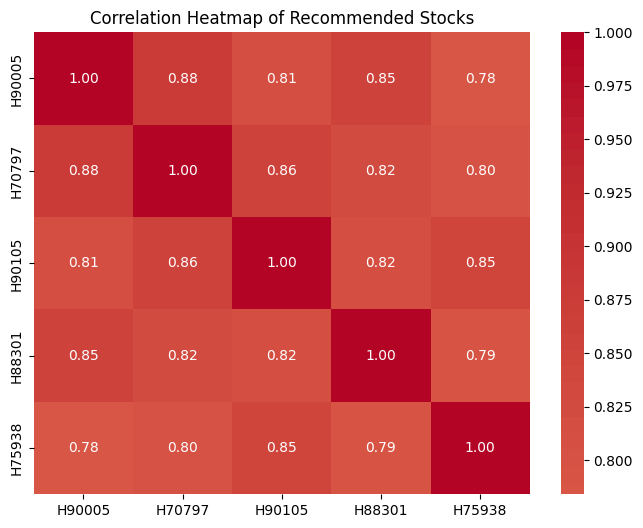

In [74]:
recommended_stock_ids = top_five_stocks["Stock_ID"].tolist()

recommended_corr_matrix = stock_df[recommended_stock_ids].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    recommended_corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Recommended Stocks")

plt.show()

The recommended stock correlation heatmap shows the relationship among the five selected stocks. Positive correlations indicate that the stocks tend to move in the same direction.

Since the recommended stocks were selected for market sensitivity, positive co-movement between them is expected.

### 17.5 Correlation Heatmap of Top 20 Market-Correlated Stocks

A heatmap is also created for the top 20 stocks with the highest market correlation. This provides a broader view of the correlation structure among market-sensitive stocks.

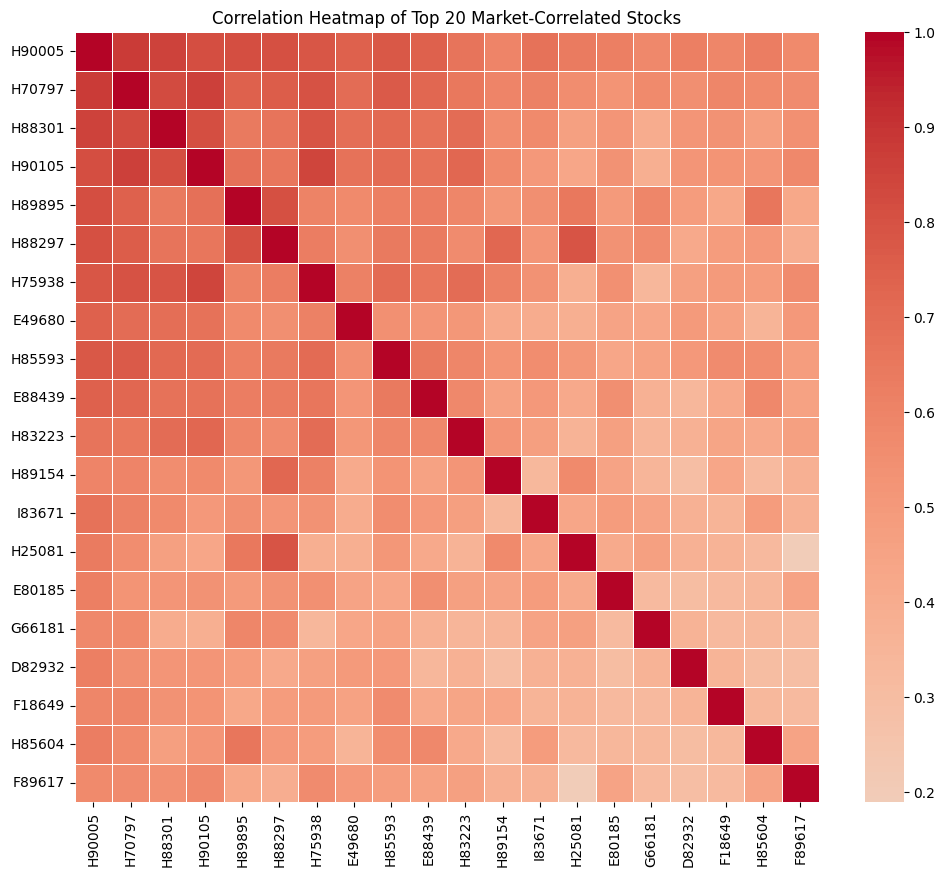

In [75]:
top_20_market_stock_ids = (
    stock_market_corr_df
    .sort_values("Market_Correlation", ascending=False)
    .head(20)["Stock_ID"]
    .tolist()
)

top_20_corr_matrix = stock_df[top_20_market_stock_ids].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    top_20_corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Top 20 Market-Correlated Stocks")

plt.show()

The heatmap of the top 20 market-correlated stocks provides a broader view of how highly market-sensitive stocks are related to each other.

Clusters of strong positive correlation suggest groups of stocks that may respond similarly to common market movements.

### 17.6 Average Within-Industry Stock Correlation

Average within-industry stock correlation is calculated to examine whether stocks from the same industry tend to move together.

In [76]:
within_industry_corr_results = []

for industry_code in stock_market_corr_df["Industry_Code"].unique():
    industry_stocks = stock_market_corr_df.loc[
        stock_market_corr_df["Industry_Code"] == industry_code,
        "Stock_ID"
    ].tolist()
    
    if len(industry_stocks) > 1:
        corr_matrix = stock_df[industry_stocks].corr()
        
        upper_triangle_values = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        ).stack()
        
        average_correlation = upper_triangle_values.mean()
        
        within_industry_corr_results.append({
            "Industry_Code": industry_code,
            "Industry_Name": industry_map[industry_code],
            "Number_of_Stocks": len(industry_stocks),
            "Average_Within_Industry_Correlation": average_correlation
        })

within_industry_corr_df = pd.DataFrame(within_industry_corr_results)

within_industry_corr_df = within_industry_corr_df.sort_values(
    "Average_Within_Industry_Correlation",
    ascending=False
)

within_industry_corr_df

,Industry_Code,Industry_Name,Number_of_Stocks,Average_Within_Industry_Correlation
1,H,"Finance, Insurance and Real Estate",37,0.295576
4,G,Retail Trade,8,0.277449
5,B,Mining,4,0.252881
0,E,Transportation and Public Utilities,18,0.223848
3,D,Manufacturing,7,0.211580
2,F,Wholesale Trade,10,0.194099
6,I,Services,8,0.163141


The within-industry correlation table shows the average correlation between stocks belonging to the same industry. Higher values suggest stronger co-movement among stocks within that industry.

This helps assess whether industry membership is associated with similar return behaviour.

### 17.7 Correlation Analysis Summary

The correlation analysis supports the earlier PCA, Factor Analysis, clustering, and stock recommendation results.

Stocks and industries with higher market correlation are more sensitive to broad market movements. The recommended stocks show strong market correlation and positive co-movement, supporting their selection for an investor seeking stocks that move closely with the market.

The stock-to-stock correlation heatmaps also provide visual evidence of co-movement among market-sensitive stocks.